In [19]:
import numpy as np
import time
import math
import warnings
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
from typing import List, Tuple, Dict, Any, Type, Optional
from abc import ABC, abstractmethod
from itertools import combinations

matplotlib.rcParams.update({
    'font.family': 'serif', 'font.size': 11, 'axes.titlesize': 13,
    'axes.labelsize': 12, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 10, 'figure.dpi': 150, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'axes.grid': True, 'grid.alpha': 0.3,
})

ACADEMIC_COLORS = ['#0072B2','#D55E00','#009E73','#CC79A7','#F0E442','#56B4E9','#E69F00','#000000']

try:
    import torch; import torch.nn as nn; import torch.optim as optim; TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False; print("PyTorch nao encontrado. DRL-MORIME desabilitado.")

try:
    from sklearn.datasets import load_breast_cancer, load_wine, load_iris, load_digits
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.svm import SVC
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.preprocessing import StandardScaler
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False; print("scikit-learn nao encontrado.")

warnings.filterwarnings('ignore')
print("Ambiente carregado com sucesso!")


Ambiente carregado com sucesso!


In [20]:
# =====================================================================
# 1. FUNCOES OBJETIVO (BENCHMARKS E MUNDO REAL)
# =====================================================================

class ObjectiveFunction(ABC):
    """Classe base abstrata para funcoes objetivo."""
    def __init__(self, dim: int, bounds: Tuple[float, float], name: str):
        self.dim = dim
        self.bounds = bounds
        self.name = name
        self.nfe = 0
        self.global_optimum = 0.0
        self.is_real_world = False

    def evaluate(self, x: np.ndarray) -> float:
        self.nfe += 1
        return self._compute(x)

    @abstractmethod
    def _compute(self, x: np.ndarray) -> float:
        pass

    def reset_nfe(self):
        self.nfe = 0

class Sphere(ObjectiveFunction):
    """Funcao Unimodal Sphere: Avalia a explotacao (convergencia limpa)."""
    def __init__(self, dim: int):
        super().__init__(dim, (-100.0, 100.0), "Sphere")
    def _compute(self, x: np.ndarray) -> float:
        return np.sum(x**2)

class Ackley(ObjectiveFunction):
    """Funcao Multimodal Ackley: Avalia a evasao de otimos locais."""
    def __init__(self, dim: int):
        super().__init__(dim, (-32.768, 32.768), "Ackley")
    def _compute(self, x: np.ndarray) -> float:
        a, b, c = 20, 0.2, 2 * np.pi
        sum_sq = np.sum(x**2)
        sum_cos = np.sum(np.cos(c * x))
        return -a * np.exp(-b * np.sqrt(sum_sq / self.dim)) - np.exp(sum_cos / self.dim) + a + np.exp(1)

class Rastrigin(ObjectiveFunction):
    """Funcao Multimodal Rastrigin: Muitos otimos locais regulares."""
    def __init__(self, dim: int):
        super().__init__(dim, (-5.12, 5.12), "Rastrigin")
    def _compute(self, x: np.ndarray) -> float:
        return 10 * self.dim + np.sum(x**2 - 10 * np.cos(2 * np.pi * x))

class Rosenbrock(ObjectiveFunction):
    """Funcao Rosenbrock (Vale/Banana): Navegar vales estreitos."""
    def __init__(self, dim: int):
        super().__init__(dim, (-30.0, 30.0), "Rosenbrock")
    def _compute(self, x: np.ndarray) -> float:
        return np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2)

class Schwefel(ObjectiveFunction):
    """Funcao Schwefel: Otimos locais nas extremidades do espaco."""
    def __init__(self, dim: int):
        super().__init__(dim, (-500.0, 500.0), "Schwefel")
    def _compute(self, x: np.ndarray) -> float:
        return 418.9829 * self.dim - np.sum(x * np.sin(np.sqrt(np.abs(x))))

class Griewank(ObjectiveFunction):
    """Funcao Griewank: Interdependencia entre variaveis."""
    def __init__(self, dim: int):
        super().__init__(dim, (-600.0, 600.0), "Griewank")
    def _compute(self, x: np.ndarray) -> float:
        sum_term = np.sum(x**2) / 4000.0
        prod_term = np.prod(np.cos(x / np.sqrt(np.arange(1, self.dim + 1))))
        return sum_term - prod_term + 1.0

# --- Problemas do Mundo Real ---

class FeatureSelectionObjective(ObjectiveFunction):
    """
    Selecao de Caracteristicas para Aprendizado de Maquina.
    Usa meta-heuristicas para selecionar o subconjunto otimo de features
    que maximiza a acuracia e minimiza a quantidade de features.
    
    Funcao Fitness: alpha * (1 - accuracy) + (1 - alpha) * (n_selected / n_total)
    
    Parametros:
        dataset_name: 'breast_cancer', 'wine', 'iris', 'digits'
        alpha: peso entre acuracia (1.0) vs parcimonia (0.0). Padrao 0.99
        classifier: 'knn', 'svm', 'dt' (Decision Tree)
        k_neighbors: numero de vizinhos para KNN (padrao 5)
        cv_folds: folds de validacao cruzada (padrao 5)
        random_state: semente para reprodutibilidade
    """
    DATASETS = {
        'breast_cancer': load_breast_cancer if SKLEARN_AVAILABLE else None,
        'wine': load_wine if SKLEARN_AVAILABLE else None,
        'iris': load_iris if SKLEARN_AVAILABLE else None,
        'digits': load_digits if SKLEARN_AVAILABLE else None,
    }
    
    def __init__(self, dataset_name: str = 'breast_cancer', alpha: float = 0.99,
                 classifier: str = 'knn', k_neighbors: int = 5,
                 cv_folds: int = 5, random_state: int = 42):
        
        if not SKLEARN_AVAILABLE:
            raise ImportError("scikit-learn e necessario para FeatureSelectionObjective")
        
        # Carregar dataset
        loader = self.DATASETS.get(dataset_name)
        if loader is None:
            raise ValueError(f"Dataset '{dataset_name}' nao encontrado. Opcoes: {list(self.DATASETS.keys())}")
        
        data = loader()
        self.X_raw = data.data
        self.y = data.target
        self.feature_names = data.feature_names if hasattr(data, 'feature_names') else [f"F{i}" for i in range(self.X_raw.shape[1])]
        
        # Normalizar features
        scaler = StandardScaler()
        self.X = scaler.fit_transform(self.X_raw)
        
        n_features = self.X.shape[1]
        super().__init__(n_features, (0.0, 1.0), f"FeatureSelection ({dataset_name})")
        self.is_real_world = True
        
        self.alpha = alpha
        self.classifier_type = classifier
        self.k_neighbors = k_neighbors
        self.cv_folds = cv_folds
        self.random_state = random_state
        self.dataset_name = dataset_name
        
        # Cache para evitar recalculos identicos
        self._cache = {}
    
    def _get_classifier(self):
        if self.classifier_type == 'knn':
            return KNeighborsClassifier(n_neighbors=self.k_neighbors)
        elif self.classifier_type == 'svm':
            return SVC(kernel='rbf', random_state=self.random_state)
        elif self.classifier_type == 'dt':
            return DecisionTreeClassifier(random_state=self.random_state)
        else:
            raise ValueError(f"Classificador '{self.classifier_type}' nao suportado. Use 'knn', 'svm' ou 'dt'.")
    
    def _compute(self, x: np.ndarray) -> float:
        # Binarizar: features com x[i] > 0.5 sao selecionadas
        selected = x > 0.5
        n_selected = np.sum(selected)
        
        # Penalizacao: se nenhuma feature selecionada, retorna custo maximo
        if n_selected == 0:
            return 1.0
        
        # Criar chave de cache (tuple de indices selecionados)
        cache_key = tuple(np.where(selected)[0])
        if cache_key in self._cache:
            return self._cache[cache_key]
        
        # Subconjunto de features selecionadas
        X_selected = self.X[:, selected]
        
        # Validacao cruzada estratificada
        clf = self._get_classifier()
        cv = StratifiedKFold(n_splits=self.cv_folds, shuffle=True, random_state=self.random_state)
        
        try:
            scores = cross_val_score(clf, X_selected, self.y, cv=cv, scoring='accuracy')
            accuracy = np.mean(scores)
        except Exception:
            accuracy = 0.0
        
        # Fitness: trade-off entre erro de classificacao e parcimonia
        error_rate = 1.0 - accuracy
        feature_ratio = n_selected / self.dim
        fitness = self.alpha * error_rate + (1.0 - self.alpha) * feature_ratio
        
        # Armazenar no cache
        self._cache[cache_key] = fitness
        return fitness


class HyperparameterOptimizationObjective(ObjectiveFunction):
    """
    Otimizacao de Hiperparametros de Modelos de Machine Learning.
    Os algoritmos operam no espaco continuo [0,1] e os valores sao
    mapeados internamente para os ranges reais dos hiperparametros.
    
    Modelos suportados:
        'svm': Otimiza C (0.01-1000) e gamma (0.0001-10)
        'rf': Otimiza n_estimators (10-300), max_depth (2-50), min_samples_split (2-20)
        'knn': Otimiza n_neighbors (1-50), weights (uniform/distance), p (1-5)
    """
    def __init__(self, model_type: str = 'svm', dataset_name: str = 'breast_cancer',
                 cv_folds: int = 5, random_state: int = 42):
        
        if not SKLEARN_AVAILABLE:
            raise ImportError("scikit-learn e necessario para HyperparameterOptimizationObjective")
        
        self.model_type = model_type
        self.cv_folds = cv_folds
        self.random_state = random_state
        self.dataset_name = dataset_name
        
        # Definir dimensionalidade por modelo
        dim_map = {'svm': 2, 'rf': 3, 'knn': 3}
        dim = dim_map.get(model_type, 2)
        
        super().__init__(dim, (0.0, 1.0), f"HPO ({model_type.upper()} - {dataset_name})")
        self.is_real_world = True
        
        # Carregar dataset
        loaders = {
            'breast_cancer': load_breast_cancer,
            'wine': load_wine,
            'iris': load_iris,
            'digits': load_digits,
        }
        data = loaders[dataset_name]()
        scaler = StandardScaler()
        self.X = scaler.fit_transform(data.data)
        self.y = data.target
        
        self._cache = {}
    
    def _decode_hyperparameters(self, x: np.ndarray) -> dict:
        """Mapeia o vetor continuo [0,1] para hiperparametros reais."""
        if self.model_type == 'svm':
            # C: [0,1] -> [0.01, 1000] (escala log)
            C = 10 ** (x[0] * 5 - 2)  # 10^(-2) a 10^(3)
            # gamma: [0,1] -> [0.0001, 10] (escala log)
            gamma = 10 ** (x[1] * 5 - 4)  # 10^(-4) a 10^(1)
            return {'C': C, 'gamma': gamma}
        
        elif self.model_type == 'rf':
            n_estimators = int(x[0] * 290 + 10)  # 10-300
            max_depth = int(x[1] * 48 + 2)       # 2-50
            min_samples_split = int(x[2] * 18 + 2)  # 2-20
            return {'n_estimators': n_estimators, 'max_depth': max_depth, 
                    'min_samples_split': min_samples_split}
        
        elif self.model_type == 'knn':
            n_neighbors = int(x[0] * 49 + 1)  # 1-50
            # weights: 0-0.5 = uniform, 0.5-1.0 = distance
            weights = 'uniform' if x[1] < 0.5 else 'distance'
            p = int(x[2] * 4 + 1)  # 1-5 (metrica Minkowski)
            return {'n_neighbors': n_neighbors, 'weights': weights, 'p': p}
    
    def _build_model(self, params: dict):
        if self.model_type == 'svm':
            return SVC(**params, random_state=self.random_state)
        elif self.model_type == 'rf':
            return RandomForestClassifier(**params, random_state=self.random_state)
        elif self.model_type == 'knn':
            return KNeighborsClassifier(**params)
    
    def _compute(self, x: np.ndarray) -> float:
        # Criar chave de cache (arredondar para evitar re-calculos quase identicos)
        cache_key = tuple(np.round(x, 4))
        if cache_key in self._cache:
            return self._cache[cache_key]
        
        params = self._decode_hyperparameters(x)
        model = self._build_model(params)
        
        cv = StratifiedKFold(n_splits=self.cv_folds, shuffle=True, random_state=self.random_state)
        
        try:
            scores = cross_val_score(model, self.X, self.y, cv=cv, scoring='accuracy')
            accuracy = np.mean(scores)
        except Exception:
            accuracy = 0.0
        
        fitness = 1.0 - accuracy  # Minimizar o erro
        self._cache[cache_key] = fitness
        return fitness


print("Secao 1: Funcoes Objetivo carregadas!")


Secao 1: Funcoes Objetivo carregadas!


In [21]:
# =====================================================================
# 2. ALGORITMOS DE OTIMIZACAO (META-HEURISTICAS)
# =====================================================================

class OptimizationAlgorithm(ABC):
    """Classe base para todos os algoritmos de otimizacao."""
    def __init__(self, pop_size: int, max_iter: int, name: str):
        self.pop_size = pop_size
        self.max_iter = max_iter
        self.name = name

    @abstractmethod
    def optimize(self, obj_func: ObjectiveFunction) -> Tuple[np.ndarray, float, np.ndarray]:
        pass
        
    def get_complexity(self, dim: int) -> str:
        return f"O({self.max_iter}*{self.pop_size}*{dim})"

class PSO(OptimizationAlgorithm):
    """Particle Swarm Optimization."""
    def __init__(self, pop_size: int, max_iter: int, c1: float = 2.0, c2: float = 2.0, w: float = 0.7):
        super().__init__(pop_size, max_iter, "PSO")
        self.c1, self.c2, self.w = c1, c2, w

    def optimize(self, obj_func: ObjectiveFunction) -> Tuple[np.ndarray, float, np.ndarray]:
        dim, (lb, ub) = obj_func.dim, obj_func.bounds
        positions = np.random.uniform(lb, ub, (self.pop_size, dim))
        velocities = np.zeros((self.pop_size, dim))
        pbest_pos = np.copy(positions)
        pbest_costs = np.array([obj_func.evaluate(p) for p in positions])
        gbest_idx = np.argmin(pbest_costs)
        gbest_pos, gbest_cost = np.copy(pbest_pos[gbest_idx]), pbest_costs[gbest_idx]
        convergence_curve = np.zeros(self.max_iter)
        
        for it in range(self.max_iter):
            r1, r2 = np.random.rand(self.pop_size, dim), np.random.rand(self.pop_size, dim)
            velocities = (self.w * velocities + self.c1 * r1 * (pbest_pos - positions) + self.c2 * r2 * (gbest_pos - positions))
            positions = np.clip(positions + velocities, lb, ub)
            for i in range(self.pop_size):
                cost = obj_func.evaluate(positions[i])
                if cost < pbest_costs[i]:
                    pbest_costs[i], pbest_pos[i] = cost, np.copy(positions[i])
                    if cost < gbest_cost:
                        gbest_cost, gbest_pos = cost, np.copy(positions[i])
            convergence_curve[it] = gbest_cost
        return gbest_pos, gbest_cost, convergence_curve

class GWO(OptimizationAlgorithm):
    """Grey Wolf Optimizer."""
    def __init__(self, pop_size: int, max_iter: int):
        super().__init__(pop_size, max_iter, "GWO")

    def optimize(self, obj_func: ObjectiveFunction) -> Tuple[np.ndarray, float, np.ndarray]:
        dim, (lb, ub) = obj_func.dim, obj_func.bounds
        positions = np.random.uniform(lb, ub, (self.pop_size, dim))
        alpha_pos, beta_pos, delta_pos = np.zeros(dim), np.zeros(dim), np.zeros(dim)
        alpha_score, beta_score, delta_score = float('inf'), float('inf'), float('inf')
        convergence_curve = np.zeros(self.max_iter)
        
        for it in range(self.max_iter):
            for i in range(self.pop_size):
                positions[i] = np.clip(positions[i], lb, ub)
                cost = obj_func.evaluate(positions[i])
                if cost < alpha_score:
                    delta_score, delta_pos = beta_score, np.copy(beta_pos)
                    beta_score, beta_pos = alpha_score, np.copy(alpha_pos)
                    alpha_score, alpha_pos = cost, np.copy(positions[i])
                elif cost < beta_score:
                    delta_score, delta_pos = beta_score, np.copy(beta_pos)
                    beta_score, beta_pos = cost, np.copy(positions[i])
                elif cost < delta_score:
                    delta_score, delta_pos = cost, np.copy(positions[i])
            
            a = 2 - it * (2 / self.max_iter)
            for i in range(self.pop_size):
                for j in range(dim):
                    r1, r2 = np.random.rand(), np.random.rand()
                    A1, C1 = 2*a*r1-a, 2*r2
                    X1 = alpha_pos[j] - A1 * abs(C1 * alpha_pos[j] - positions[i, j])
                    r1, r2 = np.random.rand(), np.random.rand()
                    A2, C2 = 2*a*r1-a, 2*r2
                    X2 = beta_pos[j] - A2 * abs(C2 * beta_pos[j] - positions[i, j])
                    r1, r2 = np.random.rand(), np.random.rand()
                    A3, C3 = 2*a*r1-a, 2*r2
                    X3 = delta_pos[j] - A3 * abs(C3 * delta_pos[j] - positions[i, j])
                    positions[i, j] = (X1 + X2 + X3) / 3.0
            convergence_curve[it] = alpha_score
        return alpha_pos, alpha_score, convergence_curve

class ACO(OptimizationAlgorithm):
    """Ant Colony Optimization (ACOR para dominios continuos)."""
    def __init__(self, pop_size: int, max_iter: int, q: float = 0.5, xi: float = 0.85):
        super().__init__(pop_size, max_iter, "ACO")
        self.q, self.xi = q, xi

    def optimize(self, obj_func: ObjectiveFunction) -> Tuple[np.ndarray, float, np.ndarray]:
        dim, (lb, ub) = obj_func.dim, obj_func.bounds
        archive = np.random.uniform(lb, ub, (self.pop_size, dim))
        costs = np.array([obj_func.evaluate(p) for p in archive])
        sort_idx = np.argsort(costs); archive, costs = archive[sort_idx], costs[sort_idx]
        convergence_curve = np.zeros(self.max_iter)
        weights = 1/(self.q*self.pop_size*np.sqrt(2*np.pi))*np.exp(-0.5*(((np.arange(1,self.pop_size+1)-1)/(self.q*self.pop_size))**2))
        probs = weights / np.sum(weights)
        
        for it in range(self.max_iter):
            new_solutions = np.zeros_like(archive)
            new_costs = np.zeros(self.pop_size)
            for i in range(self.pop_size):
                l = np.random.choice(self.pop_size, p=probs)
                sigma = self.xi * np.sum(np.abs(archive - archive[l]), axis=0) / (self.pop_size - 1)
                new_solutions[i] = np.clip(archive[l] + np.random.normal(0, 1, dim) * sigma, lb, ub)
                new_costs[i] = obj_func.evaluate(new_solutions[i])
            all_sol = np.vstack((archive, new_solutions))
            all_costs = np.concatenate((costs, new_costs))
            sort_idx = np.argsort(all_costs)
            archive, costs = all_sol[sort_idx][:self.pop_size], all_costs[sort_idx][:self.pop_size]
            convergence_curve[it] = costs[0]
        return archive[0], costs[0], convergence_curve

class ALO(OptimizationAlgorithm):
    """Ant Lion Optimizer."""
    def __init__(self, pop_size: int, max_iter: int):
        super().__init__(pop_size, max_iter, "ALO")

    def optimize(self, obj_func: ObjectiveFunction) -> Tuple[np.ndarray, float, np.ndarray]:
        dim, (lb, ub) = obj_func.dim, obj_func.bounds
        antlion_pos = np.random.uniform(lb, ub, (self.pop_size, dim))
        ant_pos = np.random.uniform(lb, ub, (self.pop_size, dim))
        antlion_scores = np.array([obj_func.evaluate(p) for p in antlion_pos])
        elite_idx = np.argmin(antlion_scores)
        elite_pos, elite_score = np.copy(antlion_pos[elite_idx]), antlion_scores[elite_idx]
        convergence_curve = np.zeros(self.max_iter)
        
        for it in range(self.max_iter):
            I = 1
            if it > self.max_iter*0.95: I = 1+10**6*(it/self.max_iter)
            elif it > self.max_iter*0.9: I = 1+10**5*(it/self.max_iter)
            elif it > self.max_iter*0.75: I = 1+10**4*(it/self.max_iter)
            elif it > self.max_iter*0.5: I = 1+10**3*(it/self.max_iter)
            elif it > self.max_iter*0.1: I = 1+10**2*(it/self.max_iter)
            c, d = lb/I, ub/I
            for i in range(self.pop_size):
                ridx = np.random.randint(0, self.pop_size)
                step = np.random.uniform(-1, 1, dim)
                RA = antlion_pos[ridx] + step*(d-c)
                RE = elite_pos + step*(d-c)
                ant_pos[i] = np.clip((RA+RE)/2.0, lb, ub)
                cost = obj_func.evaluate(ant_pos[i])
                if cost < antlion_scores[ridx]:
                    antlion_scores[ridx], antlion_pos[ridx] = cost, np.copy(ant_pos[i])
                if cost < elite_score:
                    elite_score, elite_pos = cost, np.copy(ant_pos[i])
            convergence_curve[it] = elite_score
        return elite_pos, elite_score, convergence_curve

class WOA(OptimizationAlgorithm):
    """Whale Optimization Algorithm."""
    def __init__(self, pop_size: int, max_iter: int):
        super().__init__(pop_size, max_iter, "WOA")

    def optimize(self, obj_func: ObjectiveFunction) -> Tuple[np.ndarray, float, np.ndarray]:
        dim, (lb, ub) = obj_func.dim, obj_func.bounds
        positions = np.random.uniform(lb, ub, (self.pop_size, dim))
        best_pos, best_score = np.zeros(dim), float('inf')
        convergence_curve = np.zeros(self.max_iter)
        for it in range(self.max_iter):
            a = 2 - it*(2/self.max_iter)
            a2 = -1 + it*(-1/self.max_iter)
            for i in range(self.pop_size):
                positions[i] = np.clip(positions[i], lb, ub)
                cost = obj_func.evaluate(positions[i])
                if cost < best_score:
                    best_score, best_pos = cost, np.copy(positions[i])
            for i in range(self.pop_size):
                r1, r2 = np.random.rand(), np.random.rand()
                A, C = 2*a*r1-a, 2*r2
                l, p = (a2-1)*np.random.rand()+1, np.random.rand()
                for j in range(dim):
                    if p < 0.5:
                        if abs(A) >= 1:
                            ridx = np.random.randint(0, self.pop_size)
                            positions[i,j] = positions[ridx,j] - A*abs(C*positions[ridx,j]-positions[i,j])
                        else:
                            positions[i,j] = best_pos[j] - A*abs(C*best_pos[j]-positions[i,j])
                    else:
                        dist = abs(best_pos[j]-positions[i,j])
                        positions[i,j] = dist*np.exp(l)*np.cos(l*2*np.pi)+best_pos[j]
            convergence_curve[it] = best_score
        return best_pos, best_score, convergence_curve

# --- DRL-MORIME ---
if TORCH_AVAILABLE:
    class DRLPolicy(nn.Module):
        def __init__(self, dim: int):
            super().__init__()
            self.net = nn.Sequential(nn.Linear(dim*2,64),nn.ReLU(),nn.Linear(64,64),nn.ReLU(),nn.Linear(64,dim),nn.Tanh())
        def forward(self, state):
            return self.net(state)

    class DRL_MORIME(OptimizationAlgorithm):
        """DRL-MORIME: Deep Reinforcement Learning Optimizer."""
        def __init__(self, pop_size: int, max_iter: int, lr: float = 0.01):
            super().__init__(pop_size, max_iter, "DRL-MORIME")
            self.lr = lr

        def optimize(self, obj_func: ObjectiveFunction) -> Tuple[np.ndarray, float, np.ndarray]:
            dim, (lb, ub) = obj_func.dim, obj_func.bounds
            policy = DRLPolicy(dim)
            optimizer = optim.Adam(policy.parameters(), lr=self.lr)
            positions = np.random.uniform(lb, ub, (self.pop_size, dim))
            costs = np.array([obj_func.evaluate(p) for p in positions])
            gbest_idx = np.argmin(costs)
            gbest_pos, gbest_cost = np.copy(positions[gbest_idx]), costs[gbest_idx]
            convergence_curve = np.zeros(self.max_iter)
            
            for it in range(self.max_iter):
                optimizer.zero_grad()
                pos_t = torch.tensor(positions, dtype=torch.float32)
                gbest_t = torch.tensor(gbest_pos, dtype=torch.float32).repeat(self.pop_size, 1)
                state = torch.cat([pos_t, gbest_t], dim=1)
                mean_action = policy(state)
                std = torch.ones_like(mean_action)*max(0.01, 0.5*(1-it/self.max_iter))
                dist = torch.distributions.Normal(mean_action, std)
                action_sample = dist.sample()
                step_size = (ub-lb)*0.1*(1.0-it/self.max_iter)
                new_positions = np.clip((pos_t+action_sample*step_size).detach().numpy(), lb, ub)
                new_costs = np.array([obj_func.evaluate(p) for p in new_positions])
                rewards = costs - new_costs
                rewards_t = torch.tensor(rewards, dtype=torch.float32)
                for i in range(self.pop_size):
                    if new_costs[i] < costs[i]:
                        costs[i], positions[i] = new_costs[i], new_positions[i]
                        if new_costs[i] < gbest_cost:
                            gbest_cost, gbest_pos = new_costs[i], np.copy(new_positions[i])
                if rewards_t.std() > 1e-6:
                    advantages = (rewards_t-rewards_t.mean())/(rewards_t.std()+1e-8)
                else:
                    advantages = rewards_t
                log_probs = dist.log_prob(action_sample).sum(dim=1)
                loss = -(log_probs*advantages).mean()
                if loss.requires_grad:
                    loss.backward(); optimizer.step()
                convergence_curve[it] = gbest_cost
            return gbest_pos, gbest_cost, convergence_curve

        def get_complexity(self, dim: int) -> str:
            return "O(NN Inference + Backprop)"



# --- BWO (Beluga Whale Optimization - Base) ---

class BWO(OptimizationAlgorithm):
    """
    Beluga Whale Optimization (Zhong et al., 2022).
    Mimetiza o comportamento de natacao e forrageamento das baleias beluga.
    Fases: Exploracao (whale fall), Explotacao (prey approach),
    e mecanismo de baleia-piloto para evitar otimos locais.
    """
    def __init__(self, pop_size: int, max_iter: int):
        super().__init__(pop_size, max_iter, "BWO")

    def _levy_flight(self, dim: int) -> np.ndarray:
        """Voo de Levy para passos de exploracao."""
        beta = 1.5
        sigma = (math.gamma(1 + beta) * np.sin(np.pi * beta / 2) /
                 (math.gamma((1 + beta) / 2) * beta * 2**((beta - 1) / 2)))**(1 / beta)
        u = np.random.randn(dim) * sigma
        v = np.random.randn(dim)
        step = u / (np.abs(v)**(1 / beta))
        return step

    def optimize(self, obj_func: ObjectiveFunction) -> Tuple[np.ndarray, float, np.ndarray]:
        dim, (lb, ub) = obj_func.dim, obj_func.bounds
        positions = np.random.uniform(lb, ub, (self.pop_size, dim))
        costs = np.array([obj_func.evaluate(p) for p in positions])
        
        best_idx = np.argmin(costs)
        best_pos, best_cost = np.copy(positions[best_idx]), costs[best_idx]
        convergence_curve = np.zeros(self.max_iter)
        
        for it in range(self.max_iter):
            WF = 0.1 - 0.05 * (it / self.max_iter)
            
            for i in range(self.pop_size):
                C1 = 2 * np.random.rand() - 1
                
                if np.random.rand() < WF:
                    step = self._levy_flight(dim)
                    r_idx = np.random.randint(0, self.pop_size)
                    new_pos = positions[r_idx] + step * (positions[r_idx] - positions[i])
                elif np.random.rand() < 0.5:
                    r1 = np.random.rand(dim)
                    r2 = np.random.rand(dim)
                    new_pos = best_pos + r1 * (best_pos - positions[i]) * C1 + r2 * (ub - lb) * WF
                else:
                    theta = 2 * np.pi * np.random.rand()
                    r_shrink = 1 - it / self.max_iter
                    new_pos = best_pos + r_shrink * np.cos(theta) * (best_pos - positions[i])
                
                new_pos = np.clip(new_pos, lb, ub)
                new_cost = obj_func.evaluate(new_pos)
                
                if new_cost < costs[i]:
                    costs[i], positions[i] = new_cost, new_pos
                    if new_cost < best_cost:
                        best_cost, best_pos = new_cost, np.copy(new_pos)
            
            convergence_curve[it] = best_cost
        
        return best_pos, best_cost, convergence_curve


# --- DRL-BWO (Deep Reinforcement Learning + Beluga Whale Optimization) ---

if TORCH_AVAILABLE:
    class BWOPolicy(nn.Module):
        """Rede Neural do agente DRL para o DRL-BWO."""
        def __init__(self, dim: int):
            super().__init__()
            input_size = dim * 2 + 1
            self.net = nn.Sequential(
                nn.Linear(input_size, 64), nn.ReLU(),
                nn.Linear(64, 32), nn.ReLU(),
                nn.Linear(32, 3), nn.Softmax(dim=-1)
            )
        def forward(self, state):
            return self.net(state)

    class DRL_BWO(OptimizationAlgorithm):
        """
        DRL-BWO: Deep Reinforcement Learning Beluga Whale Optimization.
        Funde o comportamento das baleias beluga com um agente DRL.
        A IA decide quando explorar (whale fall), nadar (swim) ou usar
        baleia-piloto (pilot) adaptativamente via Policy Gradient.
        """
        def __init__(self, pop_size: int, max_iter: int, lr: float = 0.01):
            super().__init__(pop_size, max_iter, "DRL-BWO")
            self.lr = lr

        def _levy_flight(self, dim: int) -> np.ndarray:
            beta = 1.5
            sigma = (math.gamma(1 + beta) * np.sin(np.pi * beta / 2) /
                     (math.gamma((1 + beta) / 2) * beta * 2**((beta - 1) / 2)))**(1 / beta)
            u = np.random.randn(dim) * sigma
            v = np.random.randn(dim)
            return u / (np.abs(v)**(1 / beta))

        def optimize(self, obj_func: ObjectiveFunction) -> Tuple[np.ndarray, float, np.ndarray]:
            dim, (lb, ub) = obj_func.dim, obj_func.bounds
            policy = BWOPolicy(dim)
            optimizer = optim.Adam(policy.parameters(), lr=self.lr)
            
            positions = np.random.uniform(lb, ub, (self.pop_size, dim))
            costs = np.array([obj_func.evaluate(p) for p in positions])
            best_idx = np.argmin(costs)
            best_pos, best_cost = np.copy(positions[best_idx]), costs[best_idx]
            convergence_curve = np.zeros(self.max_iter)
            
            for it in range(self.max_iter):
                progress = it / self.max_iter
                WF = 0.1 - 0.05 * progress
                
                pos_t = torch.tensor(positions, dtype=torch.float32)
                best_t = torch.tensor(best_pos, dtype=torch.float32).repeat(self.pop_size, 1)
                prog_t = torch.full((self.pop_size, 1), progress, dtype=torch.float32)
                state = torch.cat([pos_t, best_t, prog_t], dim=1)
                
                action_probs = policy(state)
                dist = torch.distributions.Categorical(action_probs)
                actions = dist.sample()
                
                new_positions = np.copy(positions)
                new_costs = np.copy(costs)
                
                for i in range(self.pop_size):
                    action = actions[i].item()
                    C1 = 2 * np.random.rand() - 1
                    
                    if action == 0:
                        step = self._levy_flight(dim)
                        r_idx = np.random.randint(0, self.pop_size)
                        new_pos = positions[r_idx] + step * (positions[r_idx] - positions[i])
                    elif action == 1:
                        r1 = np.random.rand(dim)
                        r2 = np.random.rand(dim)
                        new_pos = best_pos + r1 * (best_pos - positions[i]) * C1 + r2 * (ub - lb) * WF
                    else:
                        theta = 2 * np.pi * np.random.rand()
                        r_shrink = 1 - progress
                        new_pos = best_pos + r_shrink * np.cos(theta) * (best_pos - positions[i])
                    
                    new_pos = np.clip(new_pos, lb, ub)
                    new_cost = obj_func.evaluate(new_pos)
                    
                    if new_cost < costs[i]:
                        new_positions[i] = new_pos
                        new_costs[i] = new_cost
                        if new_cost < best_cost:
                            best_cost, best_pos = new_cost, np.copy(new_pos)
                
                rewards = costs - new_costs
                rewards_t = torch.tensor(rewards, dtype=torch.float32)
                
                if rewards_t.std() > 1e-6:
                    advantages = (rewards_t - rewards_t.mean()) / (rewards_t.std() + 1e-8)
                else:
                    advantages = rewards_t
                
                log_probs = dist.log_prob(actions)
                loss = -(log_probs * advantages).mean()
                
                optimizer.zero_grad()
                if loss.requires_grad:
                    loss.backward()
                    optimizer.step()
                
                positions = new_positions
                costs = new_costs
                convergence_curve[it] = best_cost
            
            return best_pos, best_cost, convergence_curve

        def get_complexity(self, dim: int) -> str:
            return "O(NN Inference + Backprop)"


# --- QL-GWO (Q-Learning Grey Wolf Optimizer) ---

class QL_GWO(OptimizationAlgorithm):
    """
    QL-GWO: Q-Learning Grey Wolf Optimizer (NFE Otimizado).
    """
    def __init__(self, pop_size: int, max_iter: int,
                 alpha: float = 0.1, gamma: float = 0.9, epsilon: float = 0.3):
        super().__init__(pop_size, max_iter, "QL-GWO")
        self.q_alpha = alpha
        self.q_gamma = gamma
        self.q_epsilon = epsilon
        self.n_states = 3
        self.n_actions = 3

    def _get_state(self, improvement_ratio: float) -> int:
        if improvement_ratio > 0.01:
            return 0  # Melhorando rapido
        elif improvement_ratio > 1e-6:
            return 1  # Melhorando devagar
        else:
            return 2  # Estagnado

    def _select_action(self, Q: np.ndarray, state: int, epsilon: float) -> int:
        if np.random.rand() < epsilon:
            return np.random.randint(0, self.n_actions)
        else:
            return np.argmax(Q[state])

    def optimize(self, obj_func: ObjectiveFunction) -> Tuple[np.ndarray, float, np.ndarray]:
        dim, (lb, ub) = obj_func.dim, obj_func.bounds
        Q = np.zeros((self.n_states, self.n_actions))
        
        positions = np.random.uniform(lb, ub, (self.pop_size, dim))
        alpha_pos, beta_pos, delta_pos = np.zeros(dim), np.zeros(dim), np.zeros(dim)
        alpha_score, beta_score, delta_score = float('inf'), float('inf'), float('inf')
        convergence_curve = np.zeros(self.max_iter)
        
        # Avaliacao Inicial (Fora do loop - so roda uma vez)
        for i in range(self.pop_size):
            cost = obj_func.evaluate(positions[i])
            if cost < alpha_score:
                delta_score, delta_pos = beta_score, np.copy(beta_pos)
                beta_score, beta_pos = alpha_score, np.copy(alpha_pos)
                alpha_score, alpha_pos = cost, np.copy(positions[i])
            elif cost < beta_score:
                delta_score, delta_pos = beta_score, np.copy(beta_pos)
                beta_score, beta_pos = cost, np.copy(positions[i])
            elif cost < delta_score:
                delta_score, delta_pos = cost, np.copy(positions[i])
                
        prev_best = float('inf')
        state = 0
        
        for it in range(self.max_iter):
            # 1. Analisa Estado e Acao
            if prev_best > 1e-300:
                improvement = (prev_best - alpha_score) / (abs(prev_best) + 1e-300)
            else:
                improvement = 0.0
            state = self._get_state(improvement)
            
            current_epsilon = self.q_epsilon * (1 - it / self.max_iter)
            action = self._select_action(Q, state, current_epsilon)
            a = 2 - it * (2 / self.max_iter)
            
            new_best_before_update = alpha_score
            
            # 2. Move todos os agentes
            for i in range(self.pop_size):
                if action == 0:
                    for j in range(dim):
                        r1, r2 = np.random.rand(), np.random.rand()
                        A1, C1 = 2*a*r1-a, 2*r2
                        X1 = alpha_pos[j] - A1 * abs(C1 * alpha_pos[j] - positions[i, j])
                        r1, r2 = np.random.rand(), np.random.rand()
                        A2, C2 = 2*a*r1-a, 2*r2
                        X2 = beta_pos[j] - A2 * abs(C2 * beta_pos[j] - positions[i, j])
                        r1, r2 = np.random.rand(), np.random.rand()
                        A3, C3 = 2*a*r1-a, 2*r2
                        X3 = delta_pos[j] - A3 * abs(C3 * delta_pos[j] - positions[i, j])
                        positions[i, j] = (X1 + X2 + X3) / 3.0
                elif action == 1:
                    for j in range(dim):
                        r1, r2 = np.random.rand(), np.random.rand()
                        A1 = 2 * (a * 0.5) * r1 - (a * 0.5)
                        C1 = 2 * r2
                        positions[i, j] = alpha_pos[j] - A1 * abs(C1 * alpha_pos[j] - positions[i, j])
                else:
                    r_idx = np.random.randint(0, self.pop_size)
                    perturbation = np.random.uniform(-1, 1, dim) * (ub - lb) * 0.1 * (1 - it/self.max_iter)
                    positions[i] = positions[r_idx] + perturbation
            
            positions = np.clip(positions, lb, ub)
            
            # 3. Avalia os NOVOS agentes (Apenas 1 avaliacao por iteracao!)
            for i in range(self.pop_size):
                cost = obj_func.evaluate(positions[i])
                if cost < alpha_score:
                    delta_score, delta_pos = beta_score, np.copy(beta_pos)
                    beta_score, beta_pos = alpha_score, np.copy(alpha_pos)
                    alpha_score, alpha_pos = cost, np.copy(positions[i])
                elif cost < beta_score:
                    delta_score, delta_pos = beta_score, np.copy(beta_pos)
                    beta_score, beta_pos = cost, np.copy(positions[i])
                elif cost < delta_score:
                    delta_score, delta_pos = cost, np.copy(positions[i])
            
            # 4. Calcula recompensa e atualiza IA
            reward = new_best_before_update - alpha_score
            if reward < 0:
                reward = -0.1
            
            if prev_best > 1e-300:
                new_improvement = (prev_best - alpha_score) / (abs(prev_best) + 1e-300)
            else:
                new_improvement = 0.0
            new_state = self._get_state(new_improvement)
            
            Q[state, action] = Q[state, action] + self.q_alpha * (
                reward + self.q_gamma * np.max(Q[new_state]) - Q[state, action]
            )
            
            prev_best = alpha_score
            convergence_curve[it] = alpha_score
        
        return alpha_pos, alpha_score, convergence_curve

    def get_complexity(self, dim: int) -> str:
        return f"O({self.max_iter}*{self.pop_size}*{dim} + Q-Table)"

print("Secao 2: Algoritmos de Otimizacao carregados!")


Secao 2: Algoritmos de Otimizacao carregados!


In [22]:
class BenchmarkPlotter:
    """Suite completa de graficos com qualidade de publicacao academica."""
    
    @staticmethod
    def plot_convergence_with_ci(all_curves: Dict[str, List[np.ndarray]], func_name: str):
        """
        Curva de convergencia aprimorada.
        Usa Mediana e Intervalo Interquartil (IQR) para robustez contra outliers,
        com marcadores e eixos embutidos (inset) para destacar a reta final (SOTA academico).
        """
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Para o zoom na convergencia final (inset plot)
        from mpl_toolkits.axes_grid1.inset_locator import inset_axes
        axins = inset_axes(ax, width="35%", height="35%", loc="center right", borderpad=2)
        
        markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p']
        linestyles = ['-', '--', '-.', ':']
        
        for idx, (algo_name, curves_list) in enumerate(all_curves.items()):
            curves_array = np.array(curves_list)
            # Usando estatisticas robustas
            median_curve = np.median(curves_array, axis=0)
            q25 = np.percentile(curves_array, 25, axis=0)
            q75 = np.percentile(curves_array, 75, axis=0)
            
            safe_median = np.maximum(median_curve, 1e-300)
            safe_q25 = np.maximum(q25, 1e-300)
            safe_q75 = np.maximum(q75, 1e-300)
            
            color = ACADEMIC_COLORS[idx % len(ACADEMIC_COLORS)]
            marker = markers[idx % len(markers)]
            ls = linestyles[idx % len(linestyles)]
            iters = np.arange(len(median_curve))
            
            # Mostrar marcadores espacados para nao poluir
            markevery = max(1, len(iters) // 15)
            
            # Plot principal
            ax.plot(iters, safe_median, label=algo_name, linewidth=2.5, color=color, 
                    linestyle=ls, marker=marker, markevery=markevery, markersize=8, markeredgecolor='white')
            ax.fill_between(iters, safe_q25, safe_q75, alpha=0.15, color=color, linewidth=0)
            
            # Plot inset (zoom nos ultimos 20% das iteracoes)
            zoom_start = int(len(iters) * 0.8)
            axins.plot(iters[zoom_start:], safe_median[zoom_start:], color=color, 
                       linestyle=ls, marker=marker, markevery=max(1, (len(iters)-zoom_start)//5),
                       markersize=6, linewidth=1.5, markeredgecolor='white')
        
        ax.set_title(f"Curva de Convergência Robusta - {func_name}", fontsize=15, fontweight='bold', pad=15)
        ax.set_xlabel("Iterações", fontsize=12)
        ax.set_ylabel("Custo Mediano (Escala Log)", fontsize=12)
        ax.set_yscale('log')
        axins.set_yscale('log')
        
        # Limpar bordas para estilo mais moderno (Tufte / Seaborn-like)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, which="major", ls="-", alpha=0.2)
        ax.grid(True, which="minor", ls=":", alpha=0.1)
        axins.grid(True, ls=":", alpha=0.3)
        
        # Configurar limites do inset plot
        axins.tick_params(axis='both', which='major', labelsize=9)
        
        ax.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0), framealpha=0.9, edgecolor='lightgray', fontsize=11)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_boxplot(results: Dict[str, Dict], func_name: str):
        """
        Boxplot com Jitter (Strip Plot) sobreposto.
        Evidencia tanto a estatistica sumarizada (quartis) quanto a nuvem de pontos real.
        """
        fig, ax = plt.subplots(figsize=(10, 6))
        algos = list(results.keys())
        data = [results[a]['best_costs'] for a in algos]
        
        # Boxplot com estilo clean
        bp = ax.boxplot(data, labels=algos, patch_artist=True, notch=False,
                        showfliers=False, widths=0.5, zorder=1,
                        medianprops=dict(color='crimson', linewidth=2.5),
                        boxprops=dict(linewidth=1.5, edgecolor='black'),
                        whiskerprops=dict(linewidth=1.5),
                        capprops=dict(linewidth=1.5))
        
        for i, patch in enumerate(bp['boxes']):
            patch.set_facecolor('white')  # Fundo branco para nao ofuscar os pontos
            patch.set_alpha(1.0)
        
        # Adicionar jitter (pontos individuais)
        for i, d in enumerate(data):
            x = np.random.normal(i + 1, 0.08, size=len(d))  # spread
            ax.scatter(x, d, color=ACADEMIC_COLORS[i % len(ACADEMIC_COLORS)], 
                       alpha=0.6, s=40, zorder=2, edgecolor='white', linewidth=0.5)
        
        ax.set_title(f"Distribuição dos Custos Finais (Boxplot + Jitter) - {func_name}", fontsize=15, fontweight='bold', pad=15)
        ax.set_ylabel("Custo Final", fontsize=12)
        ax.set_xlabel("Algoritmo", fontsize=12)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.tick_params(axis='x', labelsize=11)
        
        all_costs = np.concatenate(data)
        if np.max(all_costs) / (np.min(all_costs) + 1e-300) > 100:
            ax.set_yscale('log')
            ax.set_ylabel("Custo Final (Escala Log)", fontsize=12)
        
        plt.tight_layout()
        plt.show()
    
    @staticmethod
    def plot_violin(results: Dict[str, Dict], func_name: str):
        """
        Violin plot moderno (estilo Half-Violin / Cloud plot).
        Extremamente utilizado em artigos atuais para densidades detalhadas.
        """
        fig, ax = plt.subplots(figsize=(10, 6))
        algos = list(results.keys())
        data = [results[a]['best_costs'] for a in algos]
        
        # Criar violin plot
        parts = ax.violinplot(data, showmeans=False, showmedians=False, showextrema=False, widths=0.7)
        
        # Estilizar
        for i, pc in enumerate(parts['bodies']):
            color = ACADEMIC_COLORS[i % len(ACADEMIC_COLORS)]
            pc.set_facecolor(color)
            pc.set_edgecolor('black')
            pc.set_alpha(0.6)
            
            # Extrair estatisticas para visualizacao interna robusta
            quartile1, medians, quartile3 = np.percentile(data[i], [25, 50, 75])
            whiskers_min, whiskers_max = np.min(data[i]), np.max(data[i])
            
            # Linha vertical (whiskers)
            ax.plot([i+1, i+1], [whiskers_min, whiskers_max], color='dimgray', lw=1.5, zorder=1)
            # Box interquartil
            ax.plot([i+1, i+1], [quartile1, quartile3], color='black', lw=5, zorder=2)
            # Mediana
            ax.scatter(i+1, medians, color='white', s=40, zorder=3, edgecolor='black')

        ax.set_xticks(range(1, len(algos) + 1))
        ax.set_xticklabels(algos, fontsize=11)
        ax.set_title(f"Densidade e Quartis (Violin Plot) - {func_name}", fontsize=15, fontweight='bold', pad=15)
        ax.set_ylabel("Custo Final", fontsize=12)
        ax.set_xlabel("Algoritmo", fontsize=12)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        
        all_costs = np.concatenate(data)
        if np.max(all_costs) / (np.min(all_costs) + 1e-300) > 100:
            ax.set_yscale('log')
            ax.set_ylabel("Custo Final (Escala Log)", fontsize=12)
        
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_bar_nfe_time(all_results: Dict[str, Dict[str, Dict]], func_names: List[str]):
        """Grafico de barras agrupadas: NFE medio e Tempo medio por algoritmo/funcao."""
        if not func_names:
            return
            
        algos = list(all_results[func_names[0]].keys())
        n_algos = len(algos)
        n_funcs = len(func_names)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        x = np.arange(n_funcs)
        width = 0.8 / n_algos
        
        for i, algo in enumerate(algos):
            nfes = [np.mean(all_results[fn][algo]['nfes']) for fn in func_names]
            times = [np.mean(all_results[fn][algo]['time']) for fn in func_names]
            
            color = ACADEMIC_COLORS[i % len(ACADEMIC_COLORS)]
            offset = (i - n_algos/2 + 0.5) * width
            
            ax1.bar(x + offset, nfes, width, label=algo, color=color, alpha=0.8, edgecolor='white')
            ax2.bar(x + offset, times, width, label=algo, color=color, alpha=0.8, edgecolor='white')
        
        for ax, title, ylabel in [(ax1, "NFEs Medio por Funcao", "Numero de Avaliacoes (NFE)"),
                                   (ax2, "Tempo Medio por Funcao", "Tempo (s)")]:
            ax.set_title(title, fontsize=14, fontweight='bold')
            ax.set_ylabel(ylabel)
            ax.set_xticks(x)
            ax.set_xticklabels(func_names, rotation=30, ha='right')
            ax.legend(fontsize=9)
        
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_heatmap_ranking(all_results: Dict[str, Dict[str, Dict]], func_names: List[str]):
        """Heatmap de rankings medios (Friedman-like). Linhas=funcoes, Colunas=algoritmos."""
        if not func_names:
            return
            
        algos = list(all_results[func_names[0]].keys())
        n_algos = len(algos)
        n_funcs = len(func_names)
        
        ranking_matrix = np.zeros((n_funcs, n_algos))
        
        for fi, fn in enumerate(func_names):
            medians = [np.median(all_results[fn][a]['best_costs']) for a in algos]
            ranks = stats.rankdata(medians)
            ranking_matrix[fi] = ranks
        
        fig, ax = plt.subplots(figsize=(max(8, n_algos*1.5), max(4, n_funcs*0.8)))
        
        im = ax.imshow(ranking_matrix, cmap='RdYlGn_r', aspect='auto', vmin=1, vmax=n_algos)
        
        ax.set_xticks(range(n_algos))
        ax.set_xticklabels(algos, rotation=45, ha='right')
        ax.set_yticks(range(n_funcs))
        ax.set_yticklabels(func_names)
        
        for i in range(n_funcs):
            for j in range(n_algos):
                val = ranking_matrix[i, j]
                color = 'white' if val > n_algos * 0.6 else 'black'
                ax.text(j, i, f"{val:.1f}", ha='center', va='center', color=color, fontweight='bold')
        
        plt.colorbar(im, ax=ax, label='Ranking (1=Melhor)')
        ax.set_title("Heatmap de Rankings por Funcao Objetivo", fontsize=14, fontweight='bold')
        
        # Ranking medio geral
        avg_ranks = np.mean(ranking_matrix, axis=0)
        rank_str = " | ".join([f"{a}: {r:.2f}" for a, r in zip(algos, avg_ranks)])
        ax.set_xlabel(f"Ranking Medio Geral: {rank_str}", fontsize=10)
        
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_radar(all_results: Dict[str, Dict[str, Dict]], func_names: List[str]):
        """
        Radar Chart (Spider Plot) comparativo.
        Metricas: Melhor Custo (inv), Tempo (inv), NFE (inv), Estabilidade (inv std), Ranking.
        Todas normalizadas [0, 1] onde 1 = melhor.
        """
        if not func_names:
            return
            
        algos = list(all_results[func_names[0]].keys())
        n_algos = len(algos)
        
        # Agregar metricas sobre todas as funcoes
        metrics = {a: {'best': [], 'time': [], 'nfe': [], 'std': []} for a in algos}
        
        for fn in func_names:
            for a in algos:
                d = all_results[fn][a]
                metrics[a]['best'].append(np.median(d['best_costs']))
                metrics[a]['time'].append(np.mean(d['time']))
                metrics[a]['nfe'].append(np.mean(d['nfes']))
                metrics[a]['std'].append(np.std(d['best_costs']))
        
        # Calcular ranking medio
        ranking_matrix = np.zeros((len(func_names), n_algos))
        for fi, fn in enumerate(func_names):
            medians = [np.median(all_results[fn][a]['best_costs']) for a in algos]
            ranking_matrix[fi] = stats.rankdata(medians)
        avg_ranks = np.mean(ranking_matrix, axis=0)
        
        # Agregar em valor unico por metrica
        raw_data = {}
        for a in algos:
            raw_data[a] = [
                np.mean(metrics[a]['best']),
                np.mean(metrics[a]['time']),
                np.mean(metrics[a]['nfe']),
                np.mean(metrics[a]['std']),
                avg_ranks[algos.index(a)]
            ]
        
        labels = ['Qualidade\n(Melhor Custo)', 'Velocidade\n(Tempo)', 'Eficiencia\n(NFE)', 
                  'Estabilidade\n(Std)', 'Ranking\nGeral']
        n_metrics = len(labels)
        
        # Normalizar [0, 1] — invertido para que 1 = melhor
        all_vals = np.array([raw_data[a] for a in algos])
        mins, maxs = all_vals.min(axis=0), all_vals.max(axis=0)
        ranges = maxs - mins
        ranges[ranges == 0] = 1
        
        normalized = {}
        for a in algos:
            vals = np.array(raw_data[a])
            # Inverter: menor valor original = melhor = 1
            normalized[a] = 1.0 - (vals - mins) / ranges
        
        # Plot
        angles = np.linspace(0, 2*np.pi, n_metrics, endpoint=False).tolist()
        angles += angles[:1]
        
        fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
        
        for i, a in enumerate(algos):
            values = normalized[a].tolist()
            values += values[:1]
            color = ACADEMIC_COLORS[i % len(ACADEMIC_COLORS)]
            ax.plot(angles, values, 'o-', linewidth=2, label=a, color=color)
            ax.fill(angles, values, alpha=0.1, color=color)
        
        ax.set_thetagrids(np.degrees(angles[:-1]), labels)
        ax.set_ylim(0, 1.1)
        ax.set_title("Radar Chart — Perfil Comparativo dos Algoritmos", fontsize=14, fontweight='bold', pad=20)
        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_3d_landscape(func: ObjectiveFunction, experiments_data: Dict[str, Any]):
        """Paisagem 3D aprimorada com contorno 2D."""
        lb, ub = func.bounds
        # Limitar range para visualizacao
        plot_lb = max(lb, -50)
        plot_ub = min(ub, 50)
        
        x = np.linspace(plot_lb, plot_ub, 80)
        y = np.linspace(plot_lb, plot_ub, 80)
        X, Y = np.meshgrid(x, y)
        Z = np.zeros_like(X)
        
        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                pt = np.zeros(func.dim)
                pt[0] = X[i, j]
                if func.dim > 1: pt[1] = Y[i, j]
                Z[i, j] = func._compute(pt)
        
        algos = list(experiments_data.keys())
        n = len(algos)
        cols = min(3, n)
        rows = math.ceil(n / cols)
        
        fig = plt.figure(figsize=(6*cols, 5*rows))
        fig.suptitle(f"Paisagem 3D e Solucoes - {func.name}", fontsize=16, fontweight='bold')
        
        for idx, algo in enumerate(algos):
            ax = fig.add_subplot(rows, cols, idx+1, projection='3d')
            ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.5, edgecolor='none')
            
            data = experiments_data[algo]
            costs = data['best_costs']
            best_idx, worst_idx = np.argmin(costs), np.argmax(costs)
            best_sol, worst_sol = data['best_solutions'][best_idx], data['best_solutions'][worst_idx]
            
            bx = best_sol[0]; by = best_sol[1] if func.dim > 1 else 0
            wx = worst_sol[0]; wy = worst_sol[1] if func.dim > 1 else 0
            
            pt_b = np.zeros(func.dim); pt_b[0]=bx; pt_b[1]=by
            pt_w = np.zeros(func.dim); pt_w[0]=wx; pt_w[1]=wy
            bz, wz = func._compute(pt_b), func._compute(pt_w)
            
            ax.scatter(wx, wy, wz, color='red', s=80, marker='X', edgecolors='black', label='Pior', depthshade=False)
            ax.scatter(bx, by, bz, color='gold', s=200, marker='*', edgecolors='black', label='Melhor', depthshade=False)
            
            ax.set_title(algo, fontweight='bold')
            ax.set_xlabel('D1'); ax.set_ylabel('D2'); ax.set_zlabel('f(x)')
            ax.legend(loc='upper right', fontsize=8)
        
        plt.tight_layout()
        plt.show()

    @staticmethod
    def print_latex_table(all_results: Dict[str, Dict[str, Dict]], func_names: List[str]):
        """Tabela resumo em formato LaTeX-ready."""
        if not func_names:
            return
        
        algos = list(all_results[func_names[0]].keys())
        
        print("\n" + "="*100)
        print("TABELA RESUMO (Formato LaTeX-ready)")
        print("="*100)
        
        for fn in func_names:
            print(f"\n--- {fn} ---")
            header = f"{'Algoritmo':<15} {'Melhor':>12} {'Media':>12} {'Mediana':>12} {'Std':>12} {'Tempo(s)':>10} {'NFE':>10}"
            print(header)
            print("-" * len(header))
            
            for a in algos:
                d = all_results[fn][a]
                c = d['best_costs']
                print(f"{a:<15} {np.min(c):>12.4e} {np.mean(c):>12.4e} {np.median(c):>12.4e} "
                      f"{np.std(c):>12.4e} {np.mean(d['time']):>10.4f} {int(np.mean(d['nfes'])):>10}")
            
            # Linha LaTeX
            print(f"\n% LaTeX para {fn}:")
            print(r"\begin{tabular}{l r r r r r r}")
            print(r"\hline")
            print(r"Algoritmo & Melhor & Média & Mediana & Std & Tempo(s) & NFE \\")
            print(r"\hline")
            for a in algos:
                d = all_results[fn][a]
                c = d['best_costs']
                print(f"{a} & {np.min(c):.4e} & {np.mean(c):.4e} & {np.median(c):.4e} & "
                      f"{np.std(c):.4e} & {np.mean(d['time']):.4f} & {int(np.mean(d['nfes']))} \\\\")
            print(r"\hline")
            print(r"\end{tabular}")


    # -------------------------------------------------------------------------
    # NOVAS VISUALIZACOES (Simplificadas e em PT-BR)
    # -------------------------------------------------------------------------

    CORES_PTBR = ['#0072B2','#D55E00','#009E73','#CC79A7',
                  '#F0E442','#56B4E9','#E69F00','#000000']

    @staticmethod
    def _apply_ptbr_style():
        matplotlib.rcParams.update({
            'font.family':'serif','font.size':11,'axes.titlesize':13,
            'axes.labelsize':12,'legend.fontsize':10,'figure.dpi':150,
            'savefig.dpi':300,'savefig.bbox':'tight',
            'axes.grid':True,'grid.alpha':0.3,
        })

    @staticmethod
    def plot_tabela_ranking(all_results, func_names):
        BenchmarkPlotter._apply_ptbr_style()
        if not func_names: return
        algos = list(all_results[func_names[0]].keys())
        n_algo, n_func = len(algos), len(func_names)
        
        medianas, rankings = np.zeros((n_algo, n_func)), np.zeros((n_algo, n_func))
        for fi, fn in enumerate(func_names):
            meds = [np.median(all_results[fn][a]['best_costs']) for a in algos]
            medianas[:, fi] = meds
            rankings[:, fi] = stats.rankdata(meds)
            
        rank_medio = rankings.mean(axis=1)
        fig, ax = plt.subplots(figsize=(max(8, n_func*2), max(4, n_algo*0.8)))
        ax.axis('off')
        
        col_labels = func_names + ['Ranking\nMedio']
        tab_data = []
        for ai, a in enumerate(algos):
            linha = [f"{medianas[ai, fi]:.2e}\n(#{int(rankings[ai, fi])})" for fi in range(n_func)]
            linha.append(f"{rank_medio[ai]:.2f}")
            tab_data.append(linha)
            
        cell_colors = []
        for ai in range(n_algo):
            row_colors = []
            for fi in range(n_func):
                t = (rankings[ai, fi] - 1) / max(n_algo - 1, 1)
                row_colors.append((1.0, 1.0 - t*0.7, 1.0 - t*0.7))
            t = (rank_medio[ai] - 1) / max(n_algo - 1, 1)
            row_colors.append((1.0 - t*0.5, 1.0 - t*0.3, 1.0 - t*0.5))
            cell_colors.append(row_colors)
            
        tbl = ax.table(cellText=tab_data, rowLabels=algos, colLabels=col_labels, 
                       cellColours=cell_colors, cellLoc='center', loc='center')
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(9)
        tbl.scale(1.4, 2.0)
        ax.set_title("Tabela de Desempenho — Mediana e Ranking por Funcao\n(verde=melhor, vermelho=pior)", fontsize=13, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_win_tie_loss(all_results, func_names, alpha=0.05):
        BenchmarkPlotter._apply_ptbr_style()
        if not func_names: return
        algos = list(all_results[func_names[0]].keys())
        pares = [(algos[i], algos[j]) for i in range(len(algos)) for j in range(i+1, len(algos))]
        
        labels, win, tie, loss = [], [], [], []
        for a1, a2 in pares:
            w, t, l = 0, 0, 0
            for fn in func_names:
                c1, c2 = all_results[fn][a1]['best_costs'], all_results[fn][a2]['best_costs']
                try:
                    _, p = stats.mannwhitneyu(c1, c2, alternative='two-sided')
                    if p < alpha:
                        if np.median(c1) < np.median(c2): w += 1
                        else: l += 1
                    else: t += 1
                except ValueError: t += 1
            labels.append(f"{a1}\nvs\n{a2}")
            win.append(w); tie.append(t); loss.append(l)
            
        fig, ax = plt.subplots(figsize=(10, max(4, len(pares)*0.9)))
        y = np.arange(len(pares))
        h = 0.55
        
        ax.barh(y, win, h, color='#009E73', label='Vitoria')
        ax.barh(y, tie, h, left=win, color='#F0E442', label='Empate')
        ax.barh(y, loss, h, left=[w+t for w,t in zip(win,tie)], color='#D55E00', label='Derrota')
        
        for i, (w,t,l) in enumerate(zip(win,tie,loss)):
            if w>0: ax.text(w/2, i, str(w), ha='center', va='center', fontweight='bold', fontsize=9, color='white')
            if t>0: ax.text(w+t/2, i, str(t), ha='center', va='center', fontweight='bold', fontsize=9)
            if l>0: ax.text(w+t+l/2, i, str(l), ha='center', va='center', fontweight='bold', fontsize=9, color='white')
            
        ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=9)
        ax.set_xlabel("Numero de Funcoes Objetivo", fontsize=11)
        ax.set_title(f"Vitorias / Empates / Derrotas (Mann-Whitney, alpha={alpha})", fontsize=13, fontweight='bold')
        ax.legend(loc='lower right')
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_scatter_custo_tempo(all_results, func_names):
        BenchmarkPlotter._apply_ptbr_style()
        if not func_names: return
        algos = list(all_results[func_names[0]].keys())
        markers = ['o','s','^','D','v','<','>','p']
        fig, ax = plt.subplots(figsize=(9, 6))
        
        for fi, fn in enumerate(func_names):
            for ai, a in enumerate(algos):
                d = all_results[fn][a]
                tempo, custo = np.mean(d['time']), np.median(d['best_costs'])
                ax.scatter(tempo, max(custo, 1e-300), marker=markers[fi%len(markers)], 
                           color=BenchmarkPlotter.CORES_PTBR[ai%len(BenchmarkPlotter.CORES_PTBR)], s=120, alpha=0.8, edgecolors='black', 
                           label=f"{a} / {fn}" if fi==0 else "")
                ax.annotate(a, (tempo, max(custo, 1e-300)), textcoords="offset points", xytext=(6,3), fontsize=7)
                
        ax.set_yscale('log'); ax.set_xlabel("Tempo Medio (s)"); ax.set_ylabel("Custo Mediano Final (log)")
        ax.set_title("Trade-off: Qualidade vs. Velocidade (inferior esquerdo = ideal)", fontsize=13, fontweight='bold')
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_painel_boxplot(all_results, func_names):
        BenchmarkPlotter._apply_ptbr_style()
        if not func_names: return
        algos = list(all_results[func_names[0]].keys())
        fig, axes = plt.subplots(len(func_names), 1, figsize=(max(9, len(algos)*1.5), len(func_names)*3.5))
        if len(func_names) == 1: axes = [axes]
        
        for ax, fn in zip(axes, func_names):
            dados = [all_results[fn][a]['best_costs'] for a in algos]
            bp = ax.boxplot(dados, labels=algos, patch_artist=True, medianprops=dict(color='crimson', linewidth=2.5))
            for i, patch in enumerate(bp['boxes']):
                patch.set_facecolor(BenchmarkPlotter.CORES_PTBR[i%len(BenchmarkPlotter.CORES_PTBR)]); patch.set_alpha(0.6)
            all_c = np.concatenate(dados)
            if np.max(all_c) / (np.min(all_c[all_c>0]) + 1e-300) > 100:
                ax.set_yscale('log')
                ax.set_ylabel(f"{fn}\n(log)")
            else:
                ax.set_ylabel(fn)
            ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
            
        fig.suptitle("Distribuicao dos Custos Finais por Funcao Objetivo", fontsize=13, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_convergencia_simples(all_curves, func_name):
        BenchmarkPlotter._apply_ptbr_style()
        fig, ax = plt.subplots(figsize=(9, 5))
        for idx, (nome, curvas) in enumerate(all_curves.items()):
            media = np.mean(np.array(curvas), axis=0)
            ax.plot(np.arange(len(media)), np.maximum(media, 1e-300), label=nome, 
                    color=BenchmarkPlotter.CORES_PTBR[idx%len(BenchmarkPlotter.CORES_PTBR)], linewidth=2.0)
        ax.set_yscale('log'); ax.set_xlabel("Iteracoes"); ax.set_ylabel("Custo Medio (log)")
        ax.set_title(f"Convergencia Media — {func_name}", fontsize=13, fontweight='bold')
        ax.legend(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_barras_nfe(all_results, func_names):
        BenchmarkPlotter._apply_ptbr_style()
        if not func_names: return
        algos = list(all_results[func_names[0]].keys())
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        for ax, met, tit, ylab in zip(axes, ['nfes', 'time'], ["Avaliacoes (NFEs)", "Tempo de Execucao"], ["NFEs Medios", "Tempo Medio (s)"]):
            for fi, fn in enumerate(func_names):
                val = [np.mean(all_results[fn][a][met]) for a in algos]
                w = 0.8/len(func_names)
                ax.bar(np.arange(len(algos)) + (fi - len(func_names)/2 + 0.5)*w, val, w, label=fn, alpha=0.82)
            ax.set_xticks(np.arange(len(algos))); ax.set_xticklabels(algos, rotation=30, ha='right')
            ax.set_ylabel(ylab); ax.set_title(tit, fontweight='bold'); ax.legend(fontsize=8)
            ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
            
        fig.suptitle("Custo Computacional por Algoritmo", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_resumo_executivo(all_results, all_curves, func_names):
        BenchmarkPlotter._apply_ptbr_style()
        if not func_names: return
        algos = list(all_results[func_names[0]].keys())
        fig = plt.figure(figsize=(15, 10))
        import matplotlib.gridspec as gridspec
        gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
        
        ax1 = fig.add_subplot(gs[0, 0])
        for idx, (nome, curvas) in enumerate(all_curves[func_names[0]].items()):
            ax1.plot(np.maximum(np.mean(np.array(curvas), axis=0), 1e-300), label=nome, color=BenchmarkPlotter.CORES_PTBR[idx%len(BenchmarkPlotter.CORES_PTBR)])
        ax1.set_yscale('log'); ax1.set_title(f"Convergencia — {func_names[0]}", fontweight='bold')
        ax1.legend(fontsize=7); ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
        
        ax2 = fig.add_subplot(gs[0, 1])
        c_med = [np.mean([np.median(all_results[fn][a]['best_costs']) for fn in func_names]) for a in algos]
        ax2.bar(algos, c_med, color=[BenchmarkPlotter.CORES_PTBR[i%len(BenchmarkPlotter.CORES_PTBR)] for i in range(len(algos))], edgecolor='black')
        ax2.set_yscale('log'); ax2.set_title("Custo Mediano Medio", fontweight='bold'); ax2.tick_params(axis='x', rotation=30)
        ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
        
        ax3 = fig.add_subplot(gs[1, 0])
        t_med = [np.mean([np.mean(all_results[fn][a]['time']) for fn in func_names]) for a in algos]
        ax3.bar(algos, t_med, color=[BenchmarkPlotter.CORES_PTBR[i%len(BenchmarkPlotter.CORES_PTBR)] for i in range(len(algos))], edgecolor='black')
        ax3.set_title("Tempo Medio (s)", fontweight='bold'); ax3.tick_params(axis='x', rotation=30)
        ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)
        
        ax4 = fig.add_subplot(gs[1, 1])
        r_med = [np.mean([sorted([np.median(all_results[fn][aa]['best_costs']) for aa in algos]).index(np.median(all_results[fn][a]['best_costs']))+1 for fn in func_names]) for a in algos]
        ordem = np.argsort(r_med)
        ax4.barh([algos[i] for i in ordem], [r_med[i] for i in ordem], color=[BenchmarkPlotter.CORES_PTBR[i%len(BenchmarkPlotter.CORES_PTBR)] for i in ordem], edgecolor='black')
        ax4.set_xlabel("Ranking Medio (menor = melhor)"); ax4.set_title("Ranking Geral", fontweight='bold')
        ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)
        
        fig.suptitle("Resumo Executivo do Benchmark", fontsize=14, fontweight='bold')
        plt.show()


print("Secao 3: Modulo Grafico carregado!")



Secao 3: Modulo Grafico carregado!


In [23]:
# =====================================================================
# 4. SUITE DE TESTES E ANALISE ESTATISTICA
# =====================================================================

class OptimizationBenchmarkSuite:
    """Motor principal do framework de benchmark."""
    
    def __init__(self, config: dict):
        self.config = config
        self.experiments_data = {}  # func_name -> {algo_name -> {metrics}}
        self.all_curves = {}        # func_name -> {algo_name -> [curves]}
    
    def run_experiment(self, algorithms: List[OptimizationAlgorithm],
                       obj_func: ObjectiveFunction, runs: int = 30):
        """Executa o experimento com repeticoes estatisticas."""
        print(f"\n[{'='*60}]")
        print(f"  Experimento: {obj_func.name} | Dim: {obj_func.dim} | Runs: {runs}")
        print(f"[{'='*60}]\n")
        
        results = {algo.name: {
            'best_costs': [], 'best_solutions': [],
            'time': [], 'nfes': [], 'mean_curve': np.zeros(algorithms[0].max_iter)
        } for algo in algorithms}
        
        curves_by_algo = {algo.name: [] for algo in algorithms}
        
        for algo in algorithms:
            print(f"  Executando {algo.name} {algo.get_complexity(obj_func.dim)}...")
            all_curves = []
            
            for r in range(runs):
                obj_func.reset_nfe()
                # Setar seed para reprodutibilidade parcial
                np.random.seed(self.config.get('RANDOM_SEED', 42) + r)
                
                start_time = time.perf_counter()
                best_pos, best_cost, curve = algo.optimize(obj_func)
                exec_time = time.perf_counter() - start_time
                
                results[algo.name]['best_costs'].append(best_cost)
                results[algo.name]['best_solutions'].append(best_pos)
                results[algo.name]['time'].append(exec_time)
                results[algo.name]['nfes'].append(obj_func.nfe)
                all_curves.append(curve)
            
            results[algo.name]['mean_curve'] = np.mean(all_curves, axis=0)
            curves_by_algo[algo.name] = all_curves
            costs = results[algo.name]['best_costs']
            
            idx_best, idx_worst = np.argmin(costs), np.argmax(costs)
            print(f"    -> Melhor: {costs[idx_best]:.4e} | Pior: {costs[idx_worst]:.4e}")
            print(f"    -> Media: {np.mean(costs):.4e} | Mediana: {np.median(costs):.4e} | Std: {np.std(costs):.4e}")
            print(f"    -> Tempo Medio: {np.mean(results[algo.name]['time']):.4f}s | NFEs/run: {int(np.mean(results[algo.name]['nfes']))}\n")
        
        self.experiments_data[obj_func.name] = results
        self.all_curves[obj_func.name] = curves_by_algo
        return results

    def run_statistical_tests(self, func_name: str):
        """Testes estatisticos expandidos: Friedman, Kruskal-Wallis, Mann-Whitney, Cliff's Delta."""
        if func_name not in self.experiments_data:
            print("Execute o experimento primeiro.")
            return
        
        data = self.experiments_data[func_name]
        algos = list(data.keys())
        alpha = self.config.get('SIGNIFICANCE_LEVEL', 0.05)
        
        print(f"\n{'='*60}")
        print(f"  ANALISE ESTATISTICA — {func_name} (alpha={alpha})")
        print(f"{'='*60}")
        
        # --- Friedman ---
        if self.config.get('STAT_TEST_FRIEDMAN', True) and len(algos) > 2:
            costs_matrix = [data[a]['best_costs'] for a in algos]
            stat, p_val = stats.friedmanchisquare(*costs_matrix)
            sig = "SIGNIFICATIVO" if p_val < alpha else "Nao Significativo"
            print(f"\n  [Friedman] Chi2={stat:.4f}, p-value={p_val:.4e} -> {sig}")
        
        # --- Kruskal-Wallis ---
        if self.config.get('STAT_TEST_KRUSKAL', True) and len(algos) > 2:
            costs_matrix = [data[a]['best_costs'] for a in algos]
            stat, p_val = stats.kruskal(*costs_matrix)
            sig = "SIGNIFICATIVO" if p_val < alpha else "Nao Significativo"
            print(f"  [Kruskal-Wallis] H={stat:.4f}, p-value={p_val:.4e} -> {sig}")
        
        # --- Mann-Whitney U (Par a Par) com Cliff's Delta ---
        if self.config.get('STAT_TEST_WILCOXON', True) and len(algos) >= 2:
            print(f"\n  [Mann-Whitney U + Cliff's Delta] Par a Par:")
            print(f"  {'Par':<25} {'p-value':>12} {'Resultado':>18} {'Vantagem':>12} {'Cliff d':>10} {'Efeito':>12}")
            print(f"  {'-'*95}")
            
            for i in range(len(algos)):
                for j in range(i+1, len(algos)):
                    a1, a2 = algos[i], algos[j]
                    c1, c2 = data[a1]['best_costs'], data[a2]['best_costs']
                    
                    try:
                        stat, p_val = stats.mannwhitneyu(c1, c2, alternative='two-sided')
                        sig = "Significativo" if p_val < alpha else "Nao Signif."
                        winner = a1 if np.median(c1) < np.median(c2) else a2
                        
                        # Cliff's Delta (effect size)
                        n1, n2 = len(c1), len(c2)
                        dominance = sum(1 if x1 < x2 else (-1 if x1 > x2 else 0) 
                                       for x1 in c1 for x2 in c2)
                        cliff_d = dominance / (n1 * n2)
                        
                        # Magnitude do efeito
                        abs_d = abs(cliff_d)
                        if abs_d < 0.147: mag = "Negligivel"
                        elif abs_d < 0.33: mag = "Pequeno"
                        elif abs_d < 0.474: mag = "Medio"
                        else: mag = "Grande"
                        
                        par = f"{a1} vs {a2}"
                        print(f"  {par:<25} {p_val:>12.4e} {sig:>18} {winner:>12} {cliff_d:>10.4f} {mag:>12}")
                    except ValueError:
                        print(f"  {a1} vs {a2}: Erro (dados identicos?)")
        
        print()
    
    def show_all_plots(self, func: ObjectiveFunction):
        """Exibe todos os graficos habilitados no CONFIG."""
        fn = func.name
        if fn not in self.experiments_data:
            return
        
        results = self.experiments_data[fn]
        
        if self.config.get('PLOT_CONVERGENCE', True) and fn in self.all_curves:
            BenchmarkPlotter.plot_convergence_with_ci(self.all_curves[fn], fn)
        
        if self.config.get('PLOT_BOXPLOT', True):
            BenchmarkPlotter.plot_boxplot(results, fn)
        
        if self.config.get('PLOT_VIOLIN', True):
            BenchmarkPlotter.plot_violin(results, fn)
        
        if self.config.get('PLOT_3D_LANDSCAPE', True) and not func.is_real_world:
            BenchmarkPlotter.plot_3d_landscape(func, results)
        if self.config.get('PLOT_PAINEL_BOXPLOT', True):
            BenchmarkPlotter.plot_painel_boxplot(self.experiments_data, list(self.experiments_data.keys()))
        if self.config.get('PLOT_CONVERGENCIA_SIMPLES', True) and fn in self.all_curves:
            BenchmarkPlotter.plot_convergencia_simples(self.all_curves[fn], fn)

    
    def show_global_plots(self):
        """Graficos globais que comparam resultados entre funcoes."""
        func_names = list(self.experiments_data.keys())
        if not func_names:
            return
        
        if self.config.get('PLOT_BAR_NFE_TIME', True):
            BenchmarkPlotter.plot_bar_nfe_time(self.experiments_data, func_names)
        
        if self.config.get('PLOT_HEATMAP_RANKING', True):
            BenchmarkPlotter.plot_heatmap_ranking(self.experiments_data, func_names)
        
        if self.config.get('PLOT_RADAR', True):
            BenchmarkPlotter.plot_radar(self.experiments_data, func_names)
        
        if self.config.get('EXPORT_LATEX_TABLE', True):
            BenchmarkPlotter.print_latex_table(self.experiments_data, func_names)

        if self.config.get('PLOT_TABELA_RANKING', True):
            BenchmarkPlotter.plot_tabela_ranking(self.experiments_data, func_names)
        if self.config.get('PLOT_WIN_TIE_LOSS', True):
            BenchmarkPlotter.plot_win_tie_loss(self.experiments_data, func_names)
        if self.config.get('PLOT_SCATTER_CUSTO', True):
            BenchmarkPlotter.plot_scatter_custo_tempo(self.experiments_data, func_names)
        if self.config.get('PLOT_BARRAS_NFE', True):
            BenchmarkPlotter.plot_barras_nfe(self.experiments_data, func_names)
        if self.config.get('PLOT_RESUMO_EXECUTIVO', True):
            BenchmarkPlotter.plot_resumo_executivo(self.experiments_data, self.all_curves, func_names)


print("Secao 4: Suite de Testes carregada!")



Secao 4: Suite de Testes carregada!


  PLATAFORMA DE BENCHMARK — ALGORITMOS BIO-INSPIRADOS
  Dimensoes: 5 | Pop: 3
  Iteracoes: 25 | Runs: 3
  Seed: 42
  [HPO] Modelo: KNN | Dataset: breast_cancer | Dim: 3

[============================================================]
  Experimento: HPO (KNN - breast_cancer) | Dim: 3 | Runs: 3
[============================================================]

  Executando PSO O(25*3*3)...
    -> Melhor: 2.8117e-02 | Pior: 3.3395e-02
    -> Media: 3.1056e-02 | Mediana: 3.1657e-02 | Std: 2.1964e-03
    -> Tempo Medio: 4.0164s | NFEs/run: 78

  Executando GWO O(25*3*3)...
    -> Melhor: 2.8117e-02 | Pior: 3.3395e-02
    -> Media: 2.9876e-02 | Mediana: 2.8117e-02 | Std: 2.4884e-03
    -> Tempo Medio: 6.7045s | NFEs/run: 75

  Executando ACO O(25*3*3)...
    -> Melhor: 2.8117e-02 | Pior: 3.5134e-02
    -> Media: 3.0456e-02 | Mediana: 2.8117e-02 | Std: 3.3081e-03
    -> Tempo Medio: 10.1118s | NFEs/run: 78

  Executando WOA O(25*3*3)...
    -> Melhor: 2.8117e-02 | Pior: 3.3395e-02
    -> Media: 3

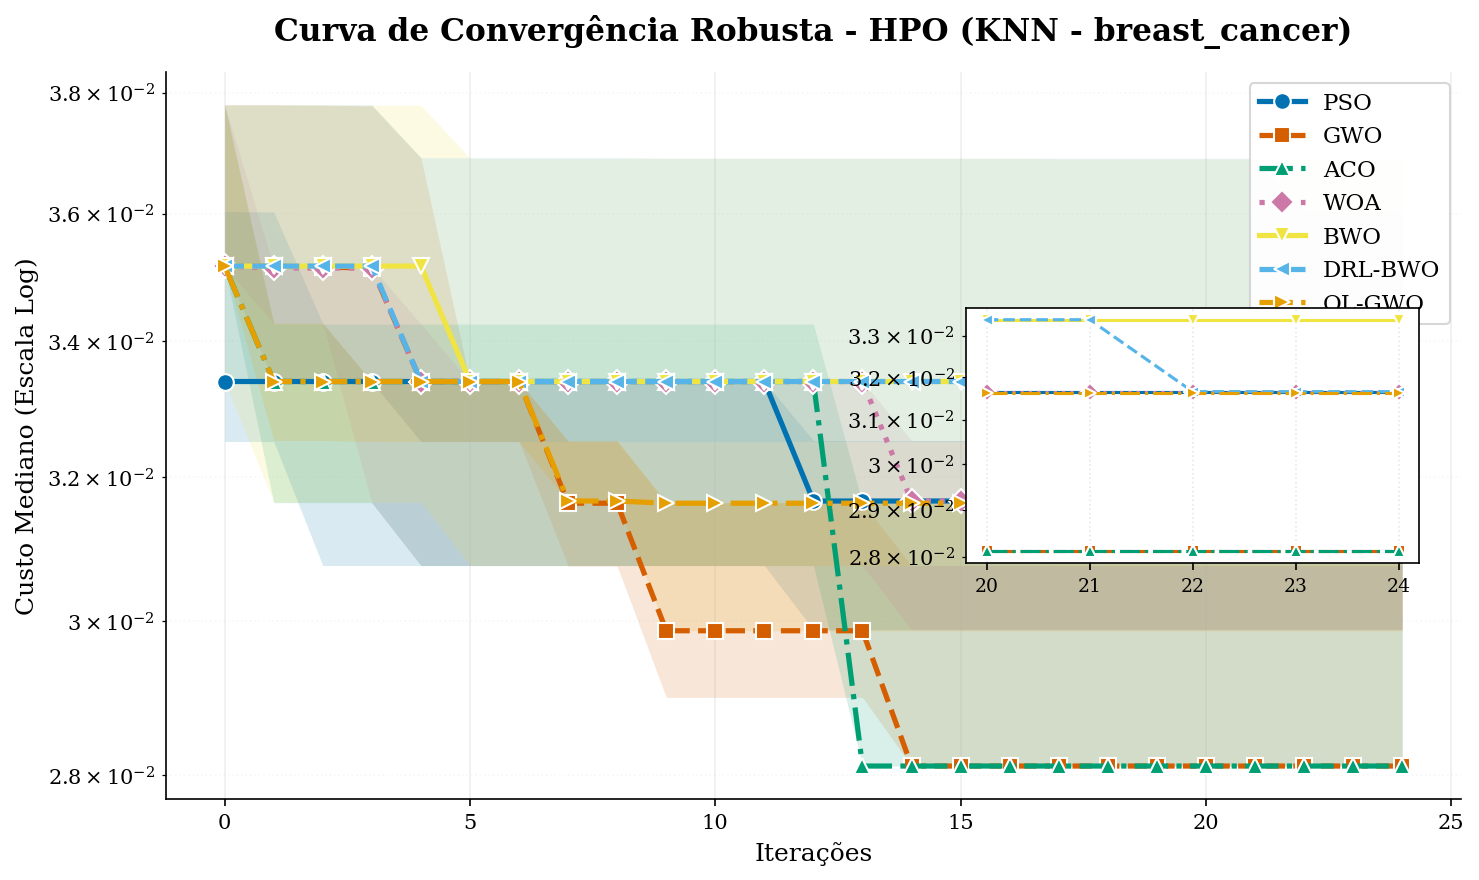

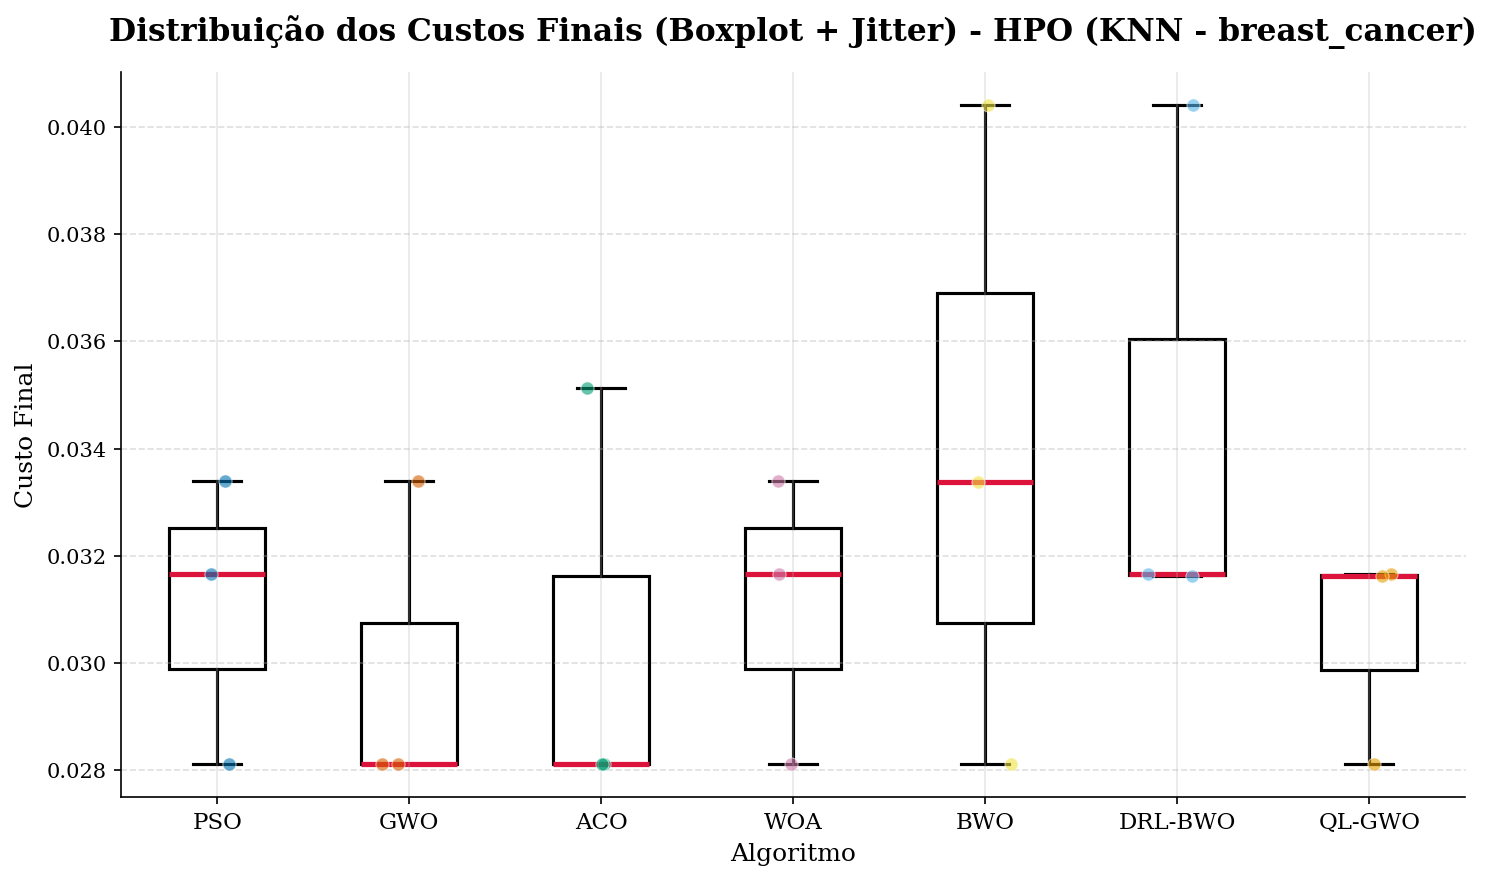

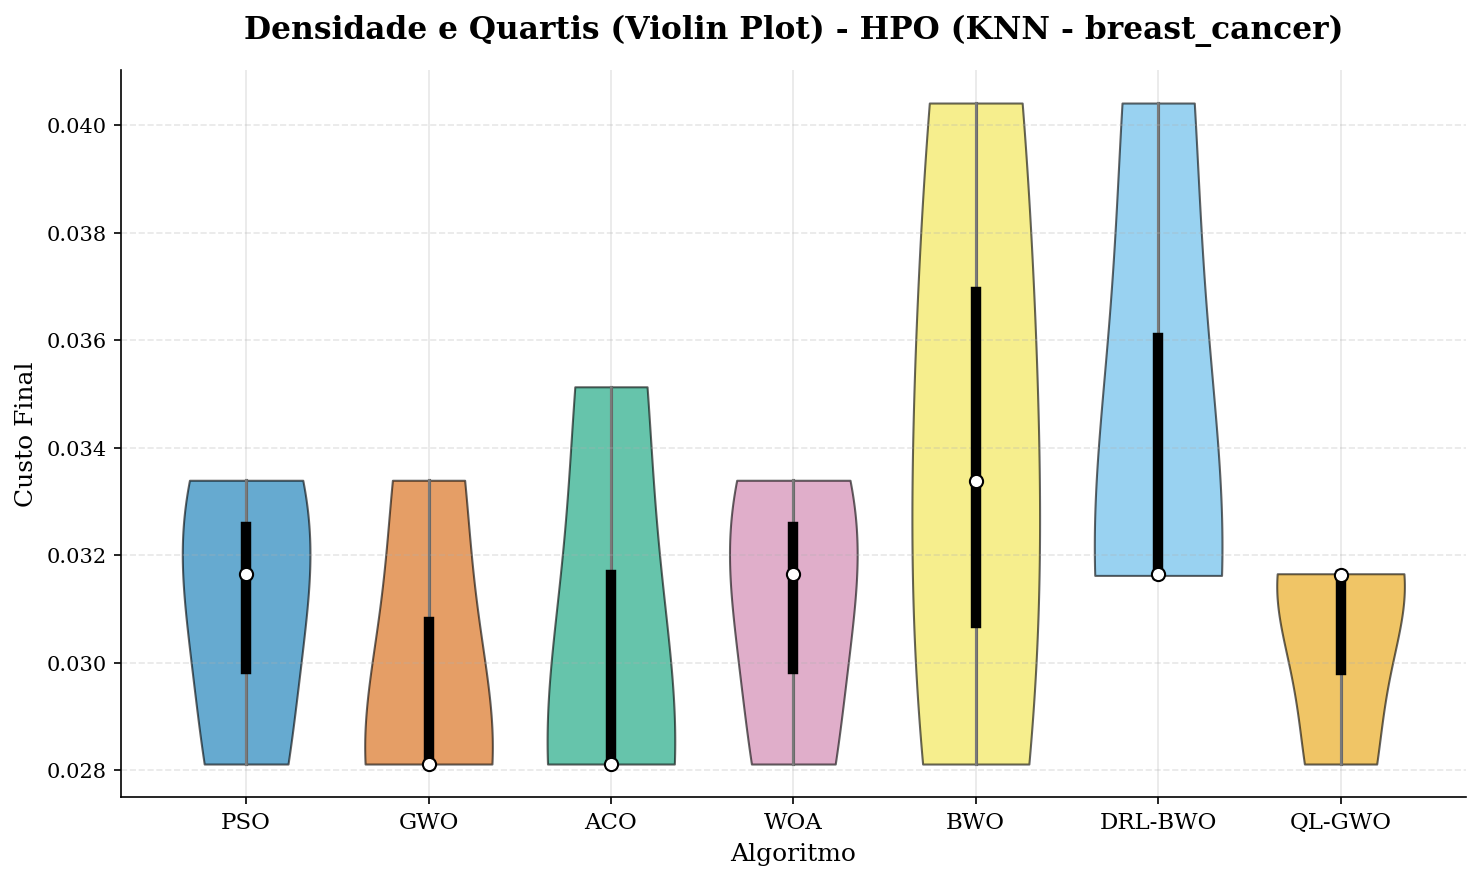

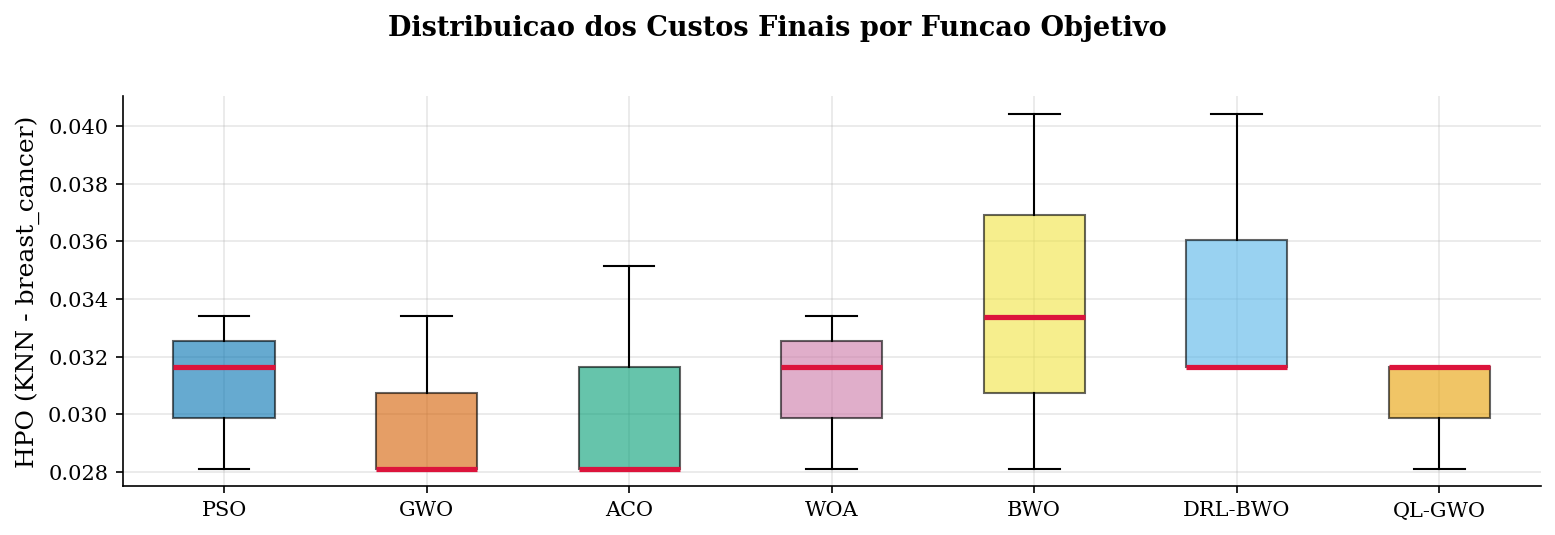

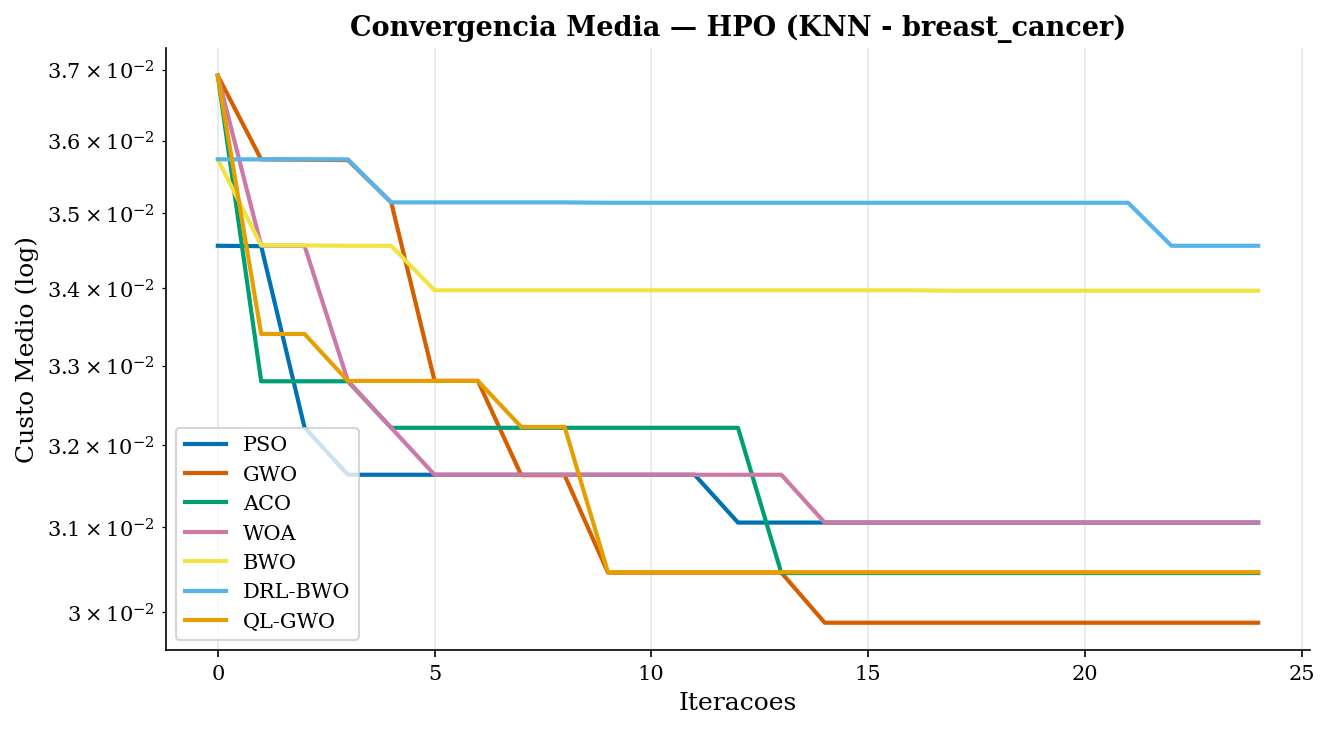


  ANALISE GLOBAL — COMPARACAO ENTRE TODAS AS FUNCOES


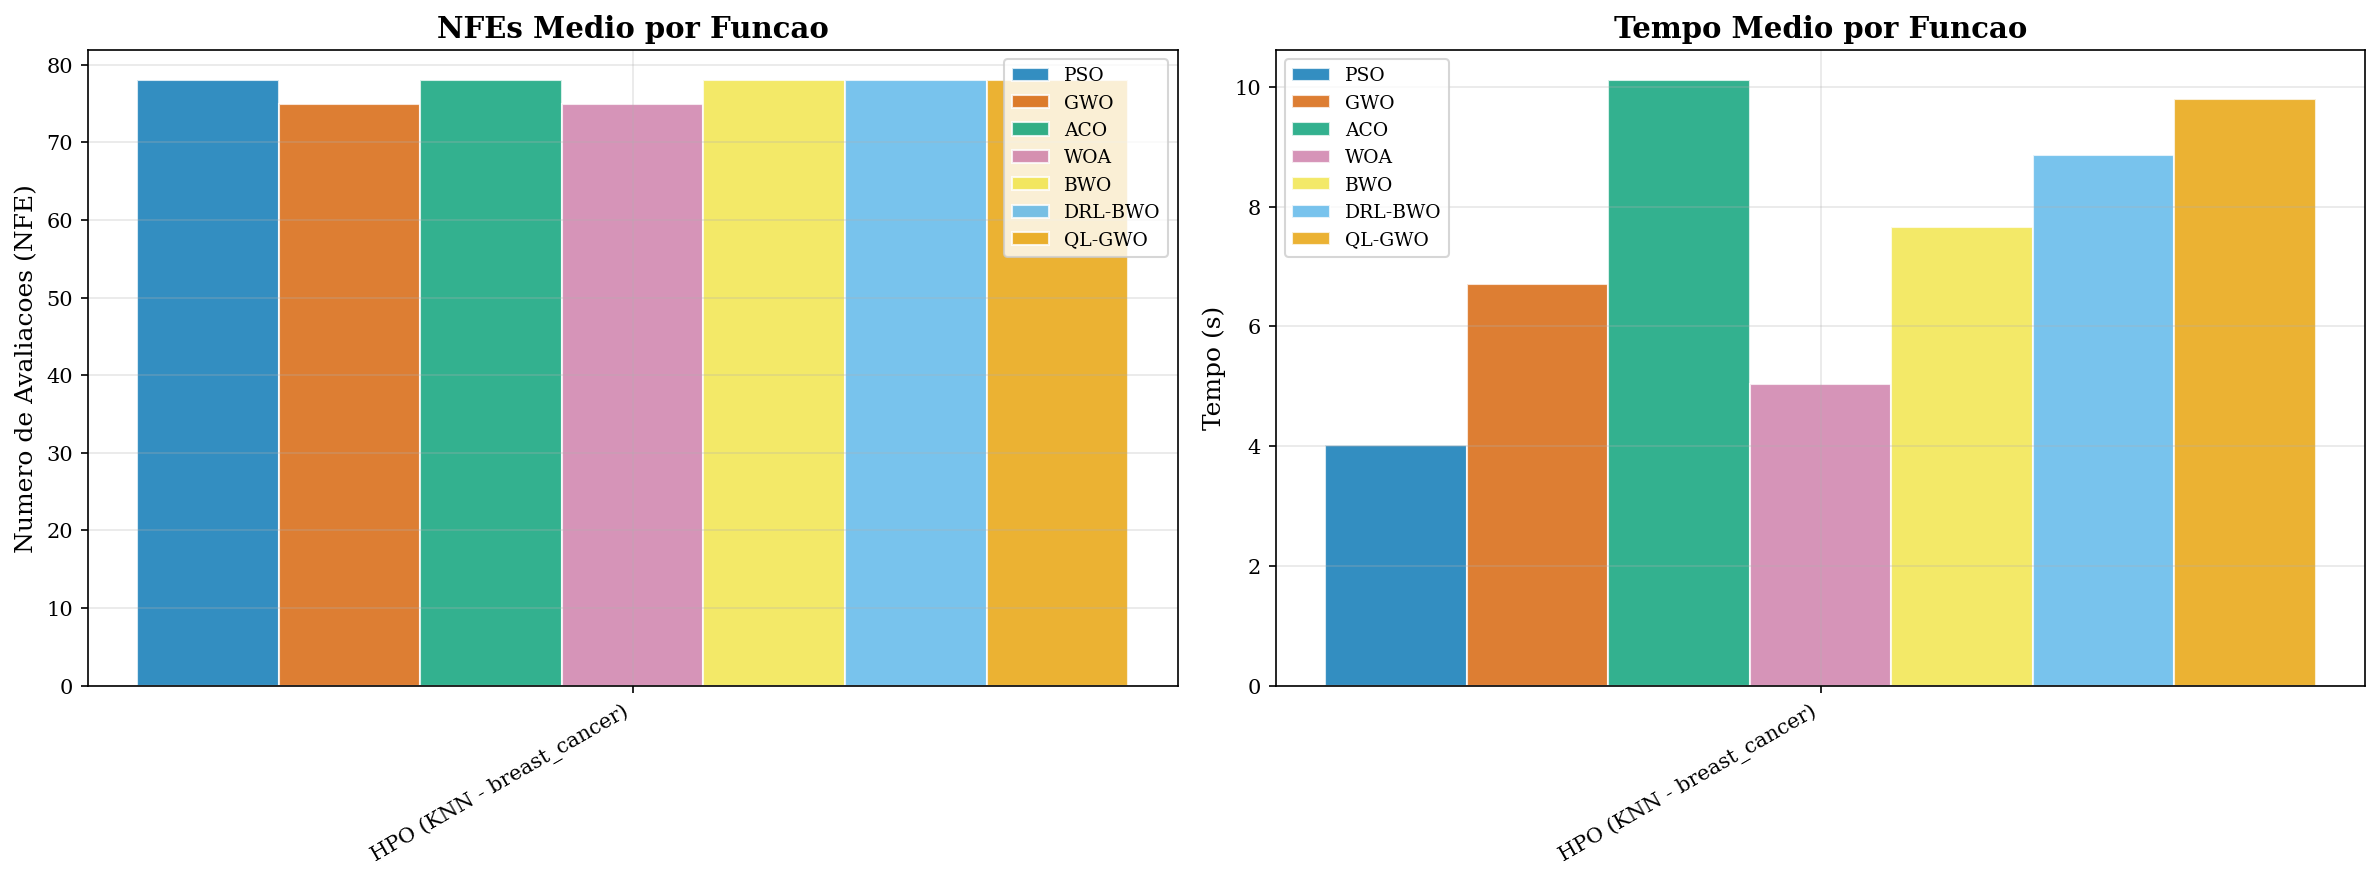

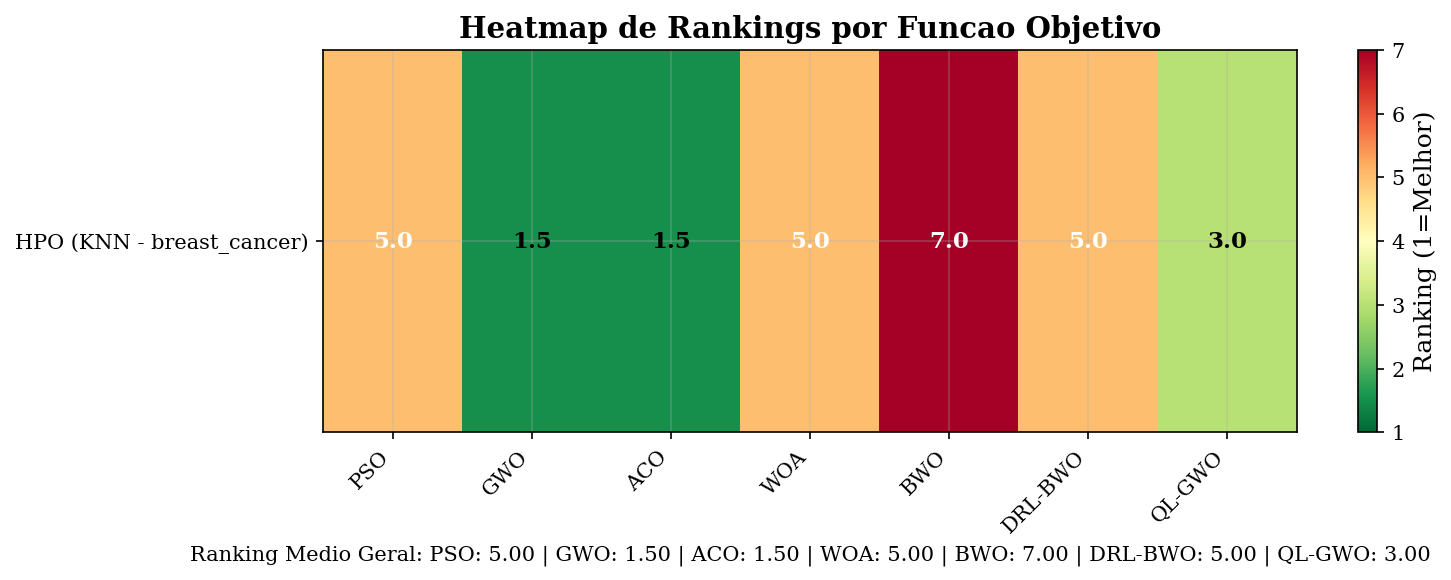

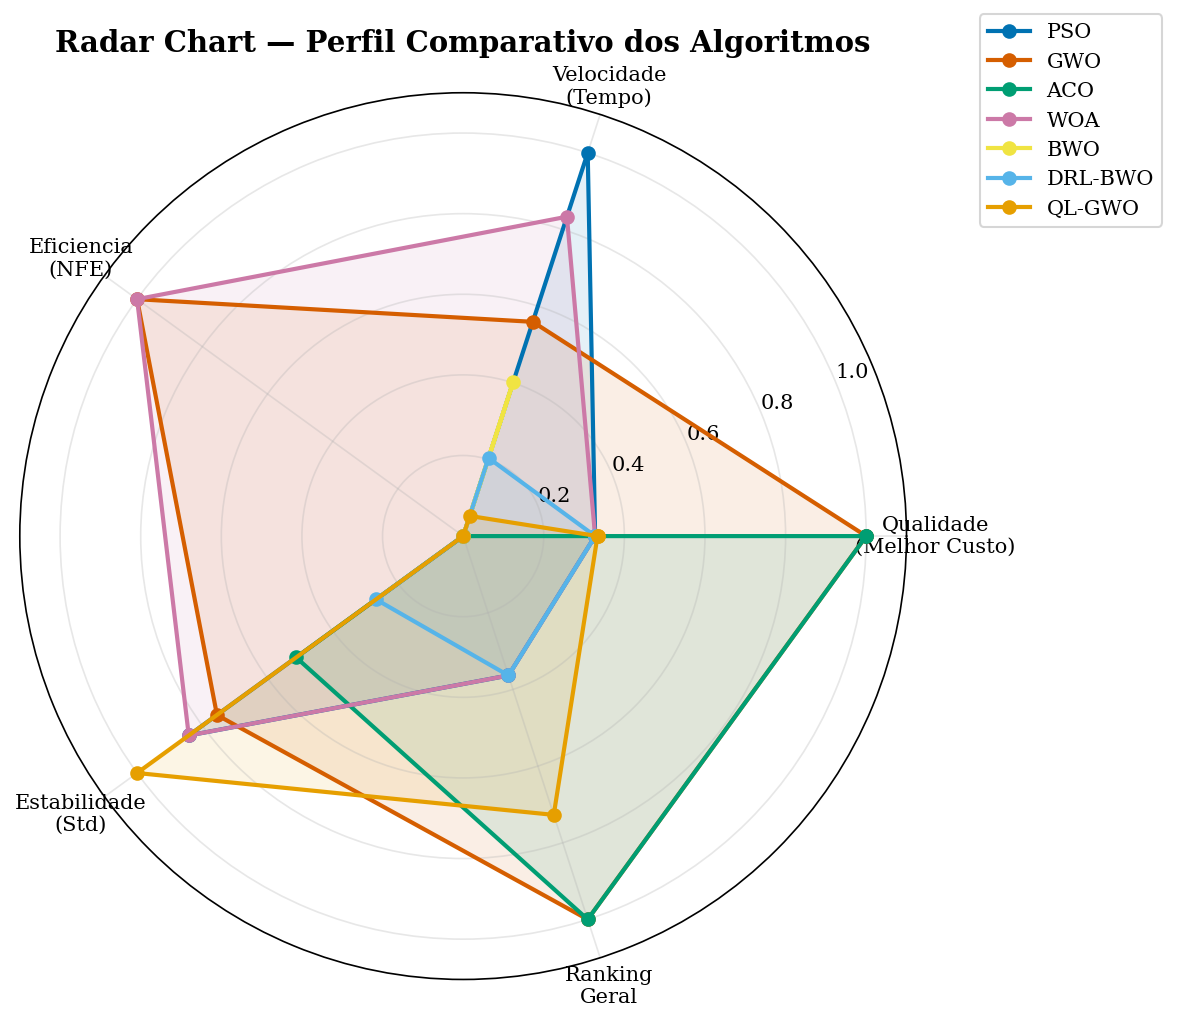


TABELA RESUMO (Formato LaTeX-ready)

--- HPO (KNN - breast_cancer) ---
Algoritmo             Melhor        Media      Mediana          Std   Tempo(s)        NFE
-----------------------------------------------------------------------------------------
PSO               2.8117e-02   3.1056e-02   3.1657e-02   2.1964e-03     4.0164         78
GWO               2.8117e-02   2.9876e-02   2.8117e-02   2.4884e-03     6.7045         75
ACO               2.8117e-02   3.0456e-02   2.8117e-02   3.3081e-03    10.1118         78
WOA               2.8117e-02   3.1056e-02   3.1657e-02   2.1964e-03     5.0331         75
BWO               2.8117e-02   3.3970e-02   3.3380e-02   5.0372e-03     7.6626         78
DRL-BWO           3.1626e-02   3.4565e-02   3.1657e-02   4.1351e-03     8.8698         78
QL-GWO            2.8117e-02   3.0466e-02   3.1626e-02   1.6614e-03     9.7911         78

% LaTeX para HPO (KNN - breast_cancer):
\begin{tabular}{l r r r r r r}
\hline
Algoritmo & Melhor & Média & Mediana & 

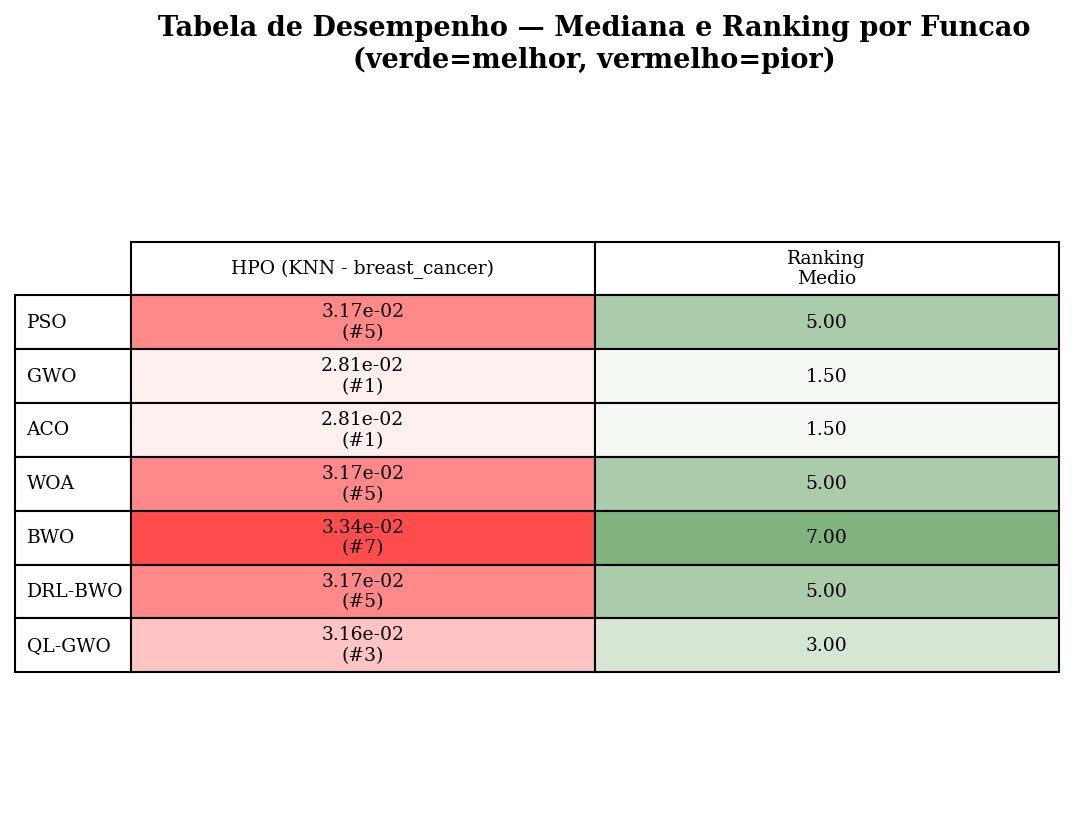

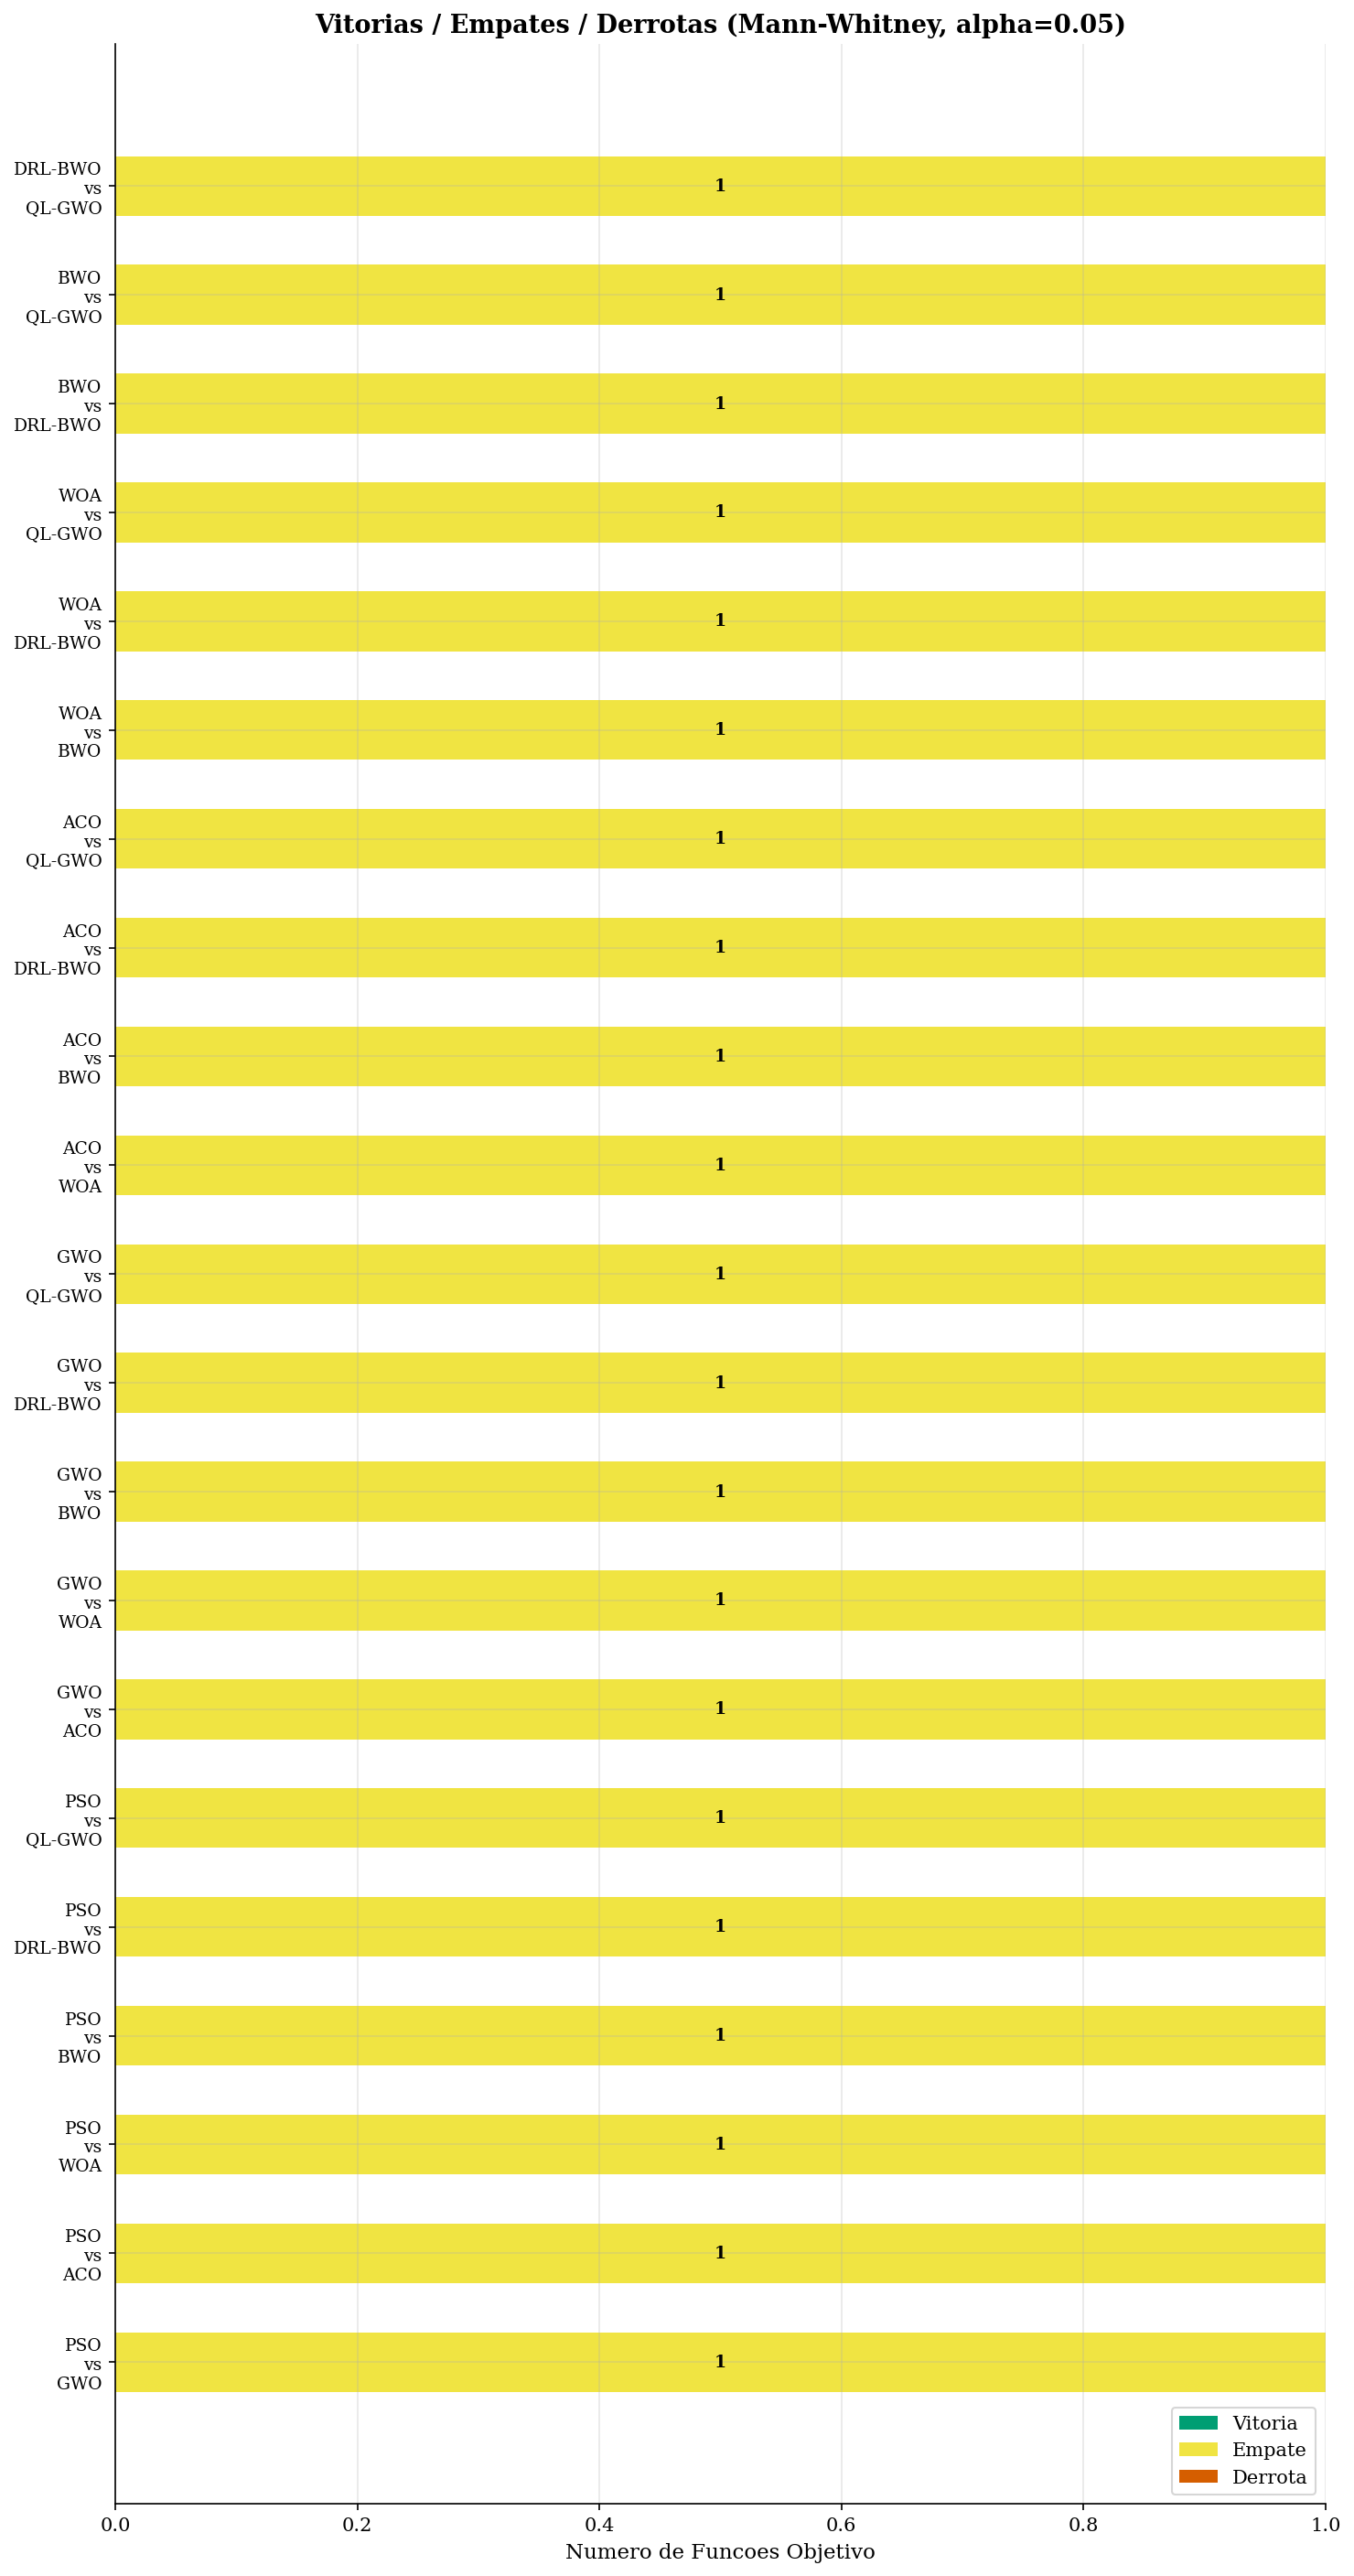

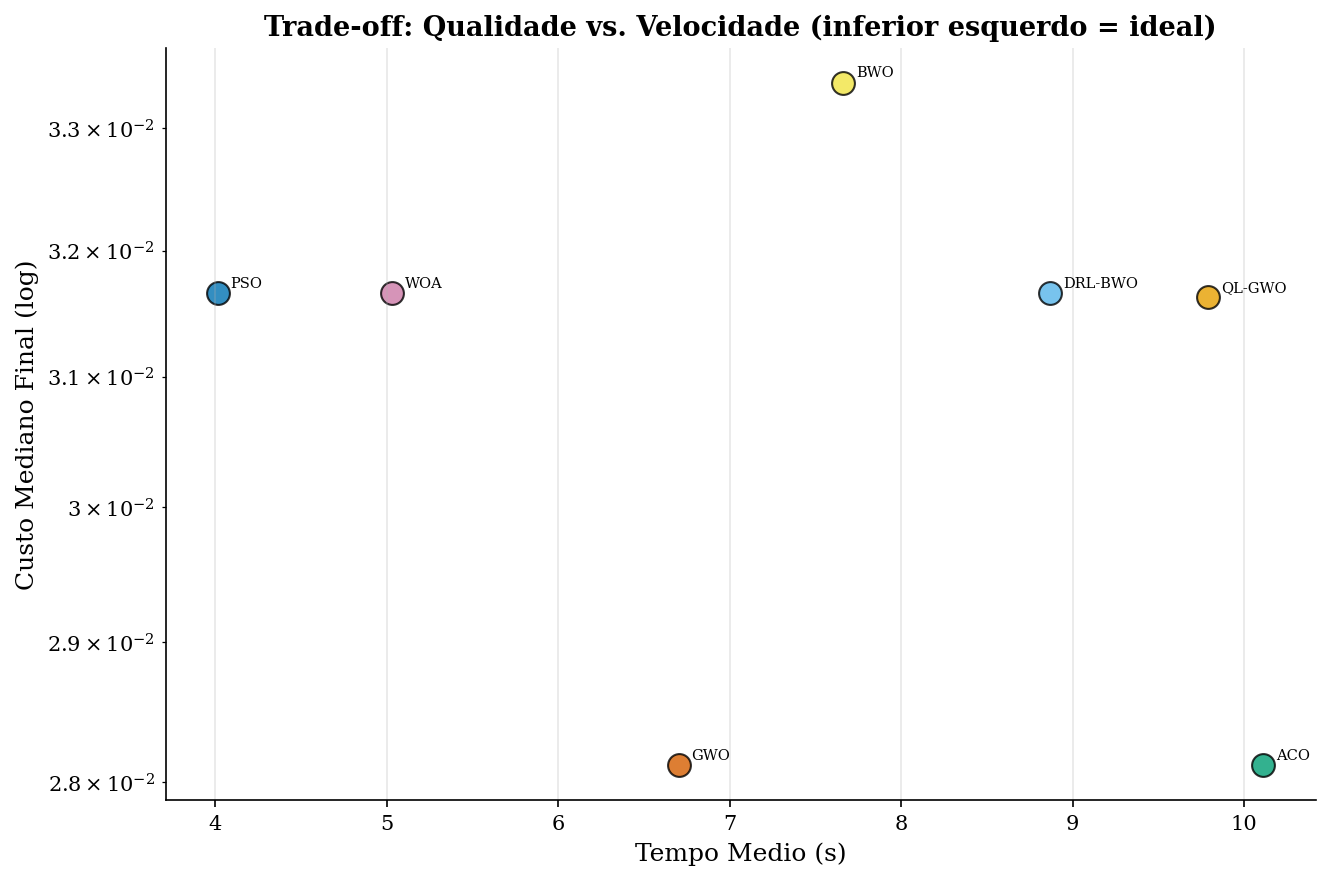

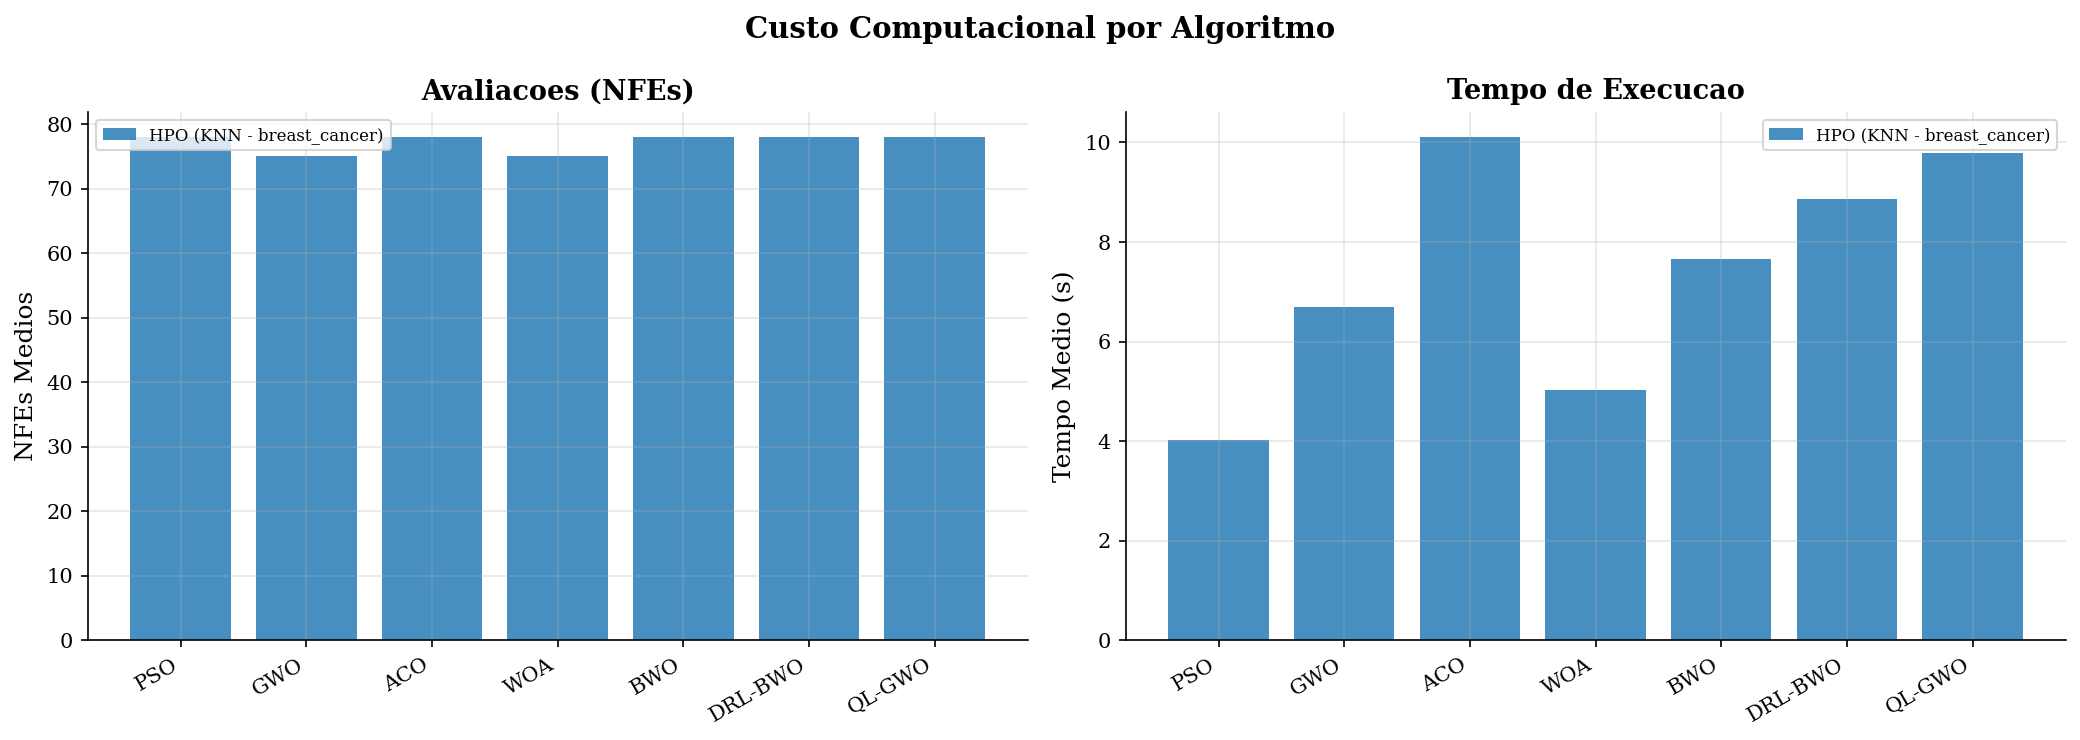

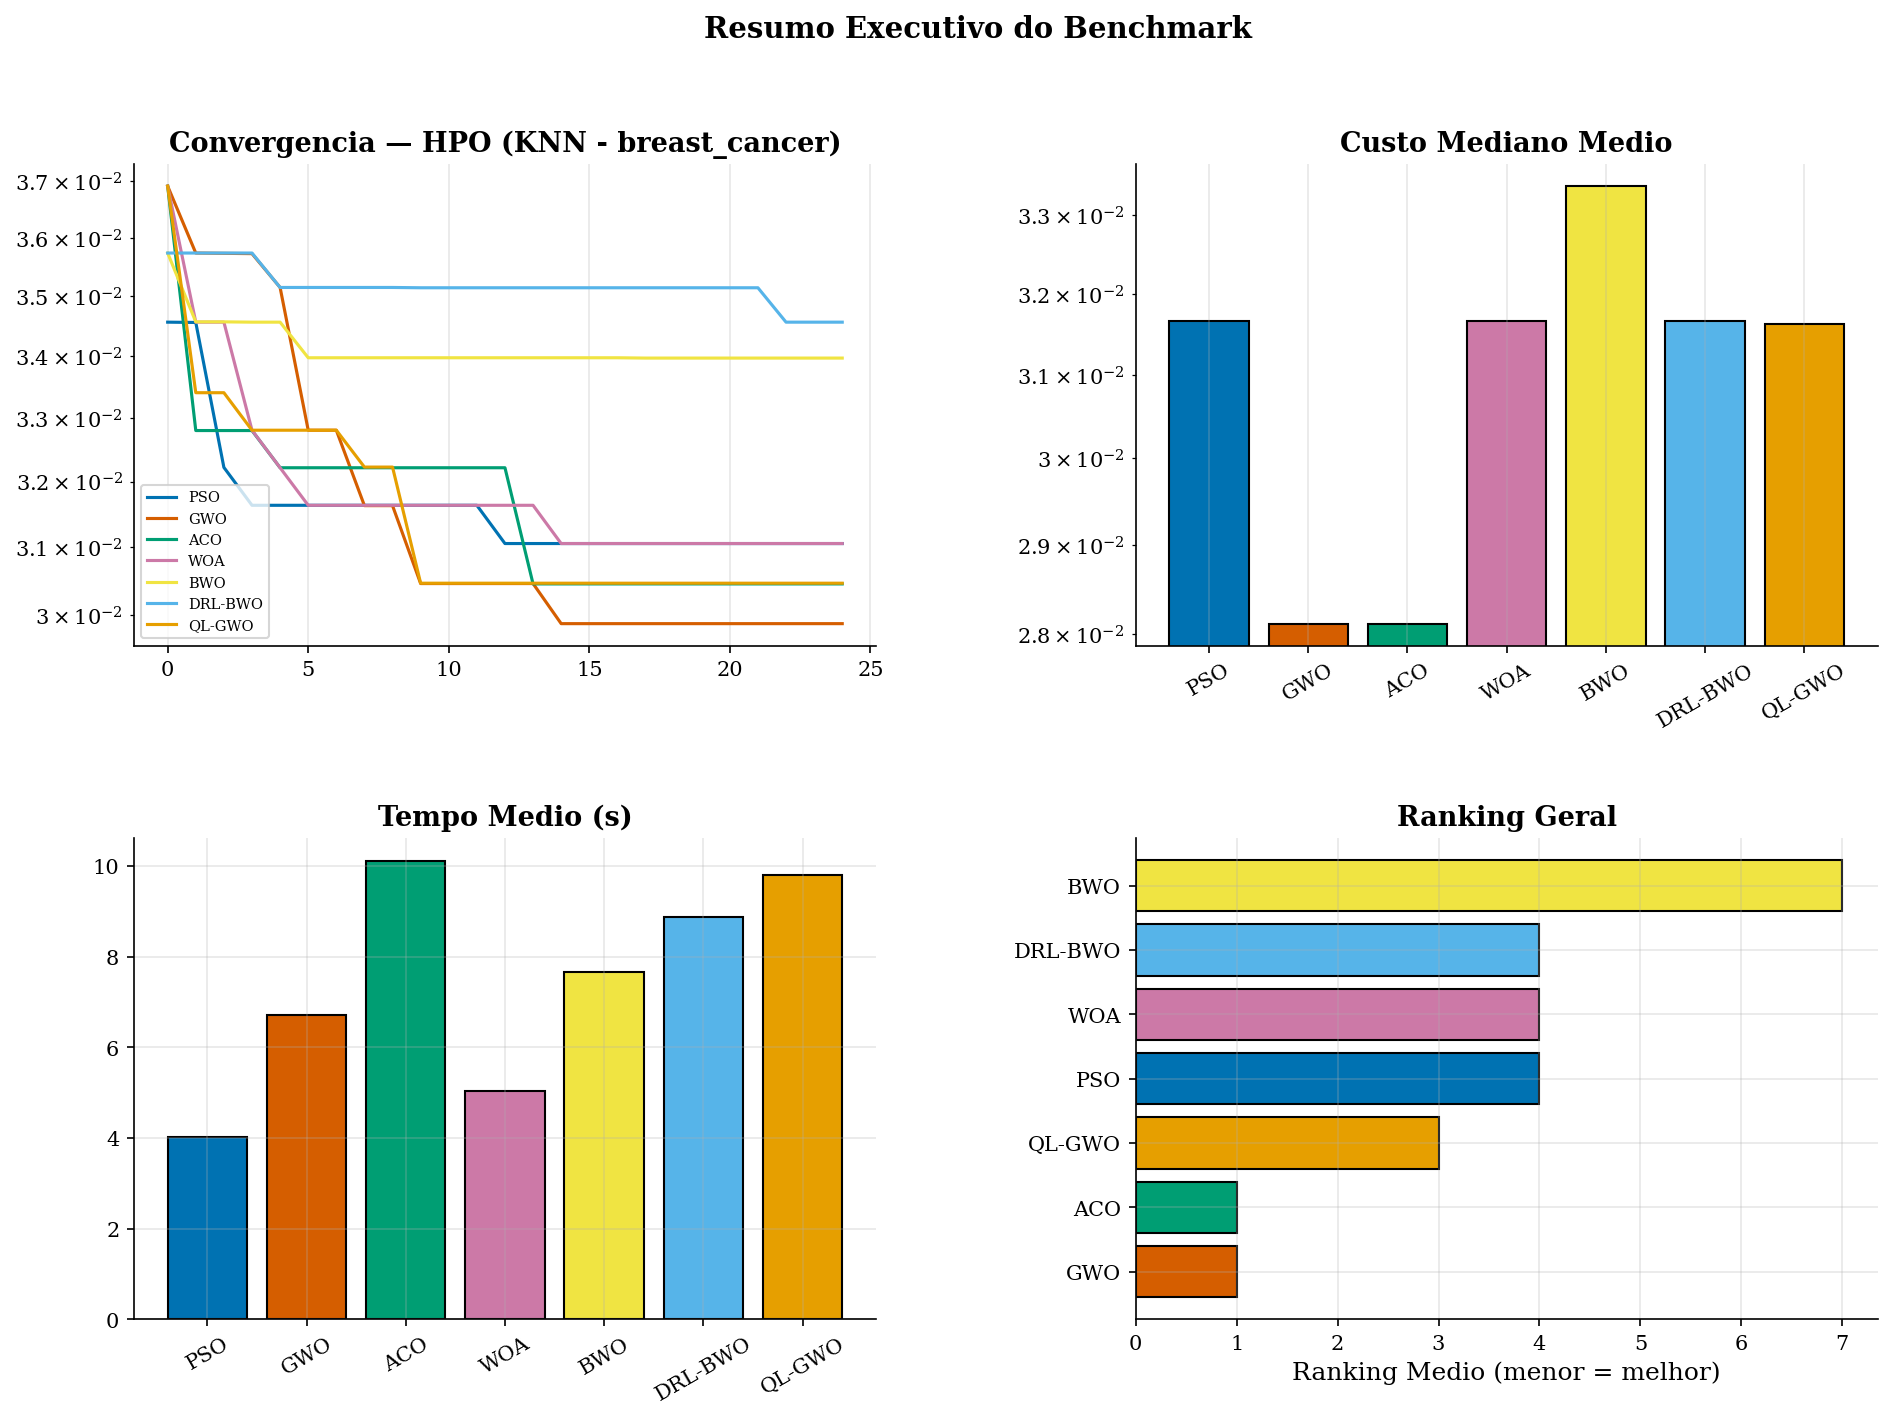


  EXPERIMENTO FINALIZADO COM SUCESSO!


In [24]:
# =====================================================================
# 5. PAINEL DE CONTROLE E EXECUCAO DO EXPERIMENTO
# =====================================================================
# INSTRUCOES: Ajuste os parametros abaixo conforme necessidade.
# Para execucao rapida de teste, use valores baixos.
# Para o TCC final, use os valores recomendados (comentados).
# =====================================================================

CONFIG = {
    # =====================================================================
    # ---- PARAMETROS GERAIS (GENERAL SETTINGS) ----
    # =====================================================================
    # DIMENSIONALITY: Controla o tamanho do problema (quantas variaveis o algoritmo deve otimizar).
    # Valores maiores aumentam exponencialmente a dificuldade geometrica (maldicao da dimensionalidade).
    # Recomendado TCC: 30 (padrao em papers). Para testes rapidos: 2, 3 ou 5.
    'DIMENSIONALITY': 5,
    
    # POPULATION_SIZE: Quantos agentes/solucoes candidatas (ex: lobos, formigas, particulas) 
    # irao explorar o espaco de busca simultaneamente a cada iteracao.
    # Recomendado TCC: 50 a 100. Para testes rapidos: 10 ou 20.
    'POPULATION_SIZE': 3,
    
    # MAX_ITERATIONS: O criterio de parada. Quantas vezes a populacao vai ser atualizada.
    # Define a convergencia maxima. Recomendado TCC: 500 ou 1000. Para testes: 50.
    'MAX_ITERATIONS': 25,
    
    # INDEPENDENT_RUNS: Numero de vezes que TODO o experimento e repetido (do zero).
    # Essencial para meta-heuristicas estocasticas, pois precisamos de uma amostra 
    # estatistica (Media, Mediana, Desvio Padrao) para provar qual algoritmo e realmente melhor.
    # Recomendado TCC: 30 (Teorema do Limite Central). Para testes rapidos: 5.
    'INDEPENDENT_RUNS': 3,
    
    # RANDOM_SEED: Semente geradora de numeros aleatorios. Garante que os testes sejam 
    # parcialmente reprodutiveis por outros pesquisadores caso usem os mesmos parametros.
    'RANDOM_SEED': 42,
    
    # =====================================================================
    # ---- SELECAO DE BENCHMARKS MATEMATICOS ----
    # =====================================================================
    # USE_BENCHMARK_FUNCTIONS: Ativa as funcoes matematicas sinteticas. Servem para isolar 
    # comportamentos (ex: Sphere testa 'explotacao', Ackley testa evasao de otimos locais).
    'USE_BENCHMARK_FUNCTIONS': False,
    'BENCHMARK_FUNCTIONS': ['Sphere', 'Ackley', 'Rastrigin', 'Rosenbrock', 'Schwefel', 'Griewank'],
    
    # =====================================================================
    # ---- PROBLEMAS DO MUNDO REAL: FEATURE SELECTION (FS) ----
    # =====================================================================
    # USE_FEATURE_SELECTION: Ativa a otimizacao de selecao de atributos em Data Science.
    # O algoritmo escolhe quais colunas de uma base de dados maximizam a acuracia de um modelo ML.
    'USE_FEATURE_SELECTION': False,
    'FS_DATASET': 'breast_cancer',     # Base de dados do Scikit-Learn
    'FS_ALPHA': 0.99,                  # Equilibrio (Trade-off): 0.99 de peso pra Acuracia e 0.01 pra Parcimonia (menos features)
    'FS_CLASSIFIER': 'knn',            # Modelo avaliador rapido ('knn' ou arvore de decisao 'dt')
    'FS_K_NEIGHBORS': 5,               # Parametro interno do KNN
    'FS_CV_FOLDS': 5,                  # Validacao cruzada (k-fold). Garante que a acuracia e real, nao sobreajustada (overfitting).
    
    # =====================================================================
    # ---- PROBLEMAS DO MUNDO REAL: HYPERPARAMETER OPTIMIZATION (HPO) ----
    # =====================================================================
    # USE_HYPERPARAMETER_OPT: Ativa o tuning de hiperparametros. O algoritmo busca 
    # a melhor combinacao de C, Gamma (para SVM) ou Layers/Estimators (Random Forest).
    'USE_HYPERPARAMETER_OPT': True,
    'HPO_MODEL': 'knn',             # Modelos suportados (HPO_MODEL):
                                    # 'svm' (Máquina de Vetores de Suporte - Otimiza as margens C e Gamma)
                                    # 'rf' (Random Forest - Otimiza número de árvores, profundidade e divisões)
                                    # 'knn' (K-Nearest Neighbors - Otimiza número de vizinhos e tipo de distância)
    
    'HPO_DATASET': 'breast_cancer', # Bases de dados suportadas (HPO_DATASET):
                                    # 'breast_cancer' (Diagnóstico de câncer)
                                    # 'wine' (Classificação de vinhos)
                                    # 'iris' (Classificação de plantas)
                                    # 'digits' (Reconhecimento de números/dígitos)

    'HPO_CV_FOLDS': 5,# Validacao cruzada em 5 folds (recomendado)
    
    # =====================================================================
    # ---- PARAMETROS INTERNOS DOS ALGORITMOS ----
    # =====================================================================
    # Valores padroes consagrados na literatura para cada metodo bio-inspirado.
    'PSO_C1': 2.0,                     # Aceleracao Cognitiva (PSO) - Memoria propria
    'PSO_C2': 2.0,                     # Aceleracao Social (PSO) - Influencia do lider
    'PSO_W': 0.7,                      # Inercia (PSO) - Taxa de exploracao global
    'ACO_Q': 0.5,                      # Parametro de intensificacao do feromonio (ACO)
    'ACO_XI': 0.85,                    # Desvio padrao de busca continua (ACO)
    'DRL_LR': 0.01,
    'DRL_BWO_LR': 0.01,                # Learning Rate do DRL-BWO
    'QL_GWO_ALPHA': 0.1,               # Taxa de aprendizado do Q-Learning (QL-GWO)
    'QL_GWO_GAMMA': 0.9,               # Fator de desconto do Q-Learning (QL-GWO)
    'QL_GWO_EPSILON': 0.3,             # Taxa de exploracao epsilon-greedy (QL-GWO)                   
    
     # Learning Rate do Reinforcement Learning (Se disponivel)
    
    # =====================================================================
    # ---- SELECAO DE ALGORITMOS (COMPETIDORES) ----
    # =====================================================================
    # Permite ligar/desligar algoritmos especificos da corrida.
    'USE_PSO': True,                   # Particle Swarm Optimization (Passaros)
    'USE_GWO': True,                   # Grey Wolf Optimizer (Lobos)
    'USE_ACO': True,                   # Ant Colony Optimization (Formigas)
    'USE_ALO': False,                   # Ant Lion Optimizer (Formigas-Leao)
    'USE_WOA': True,                   # Whale Optimization Algorithm (Baleias)
    'USE_DRL': False,                   # Deep Reinforcement Learning Meta-heuristic (Hibrido)
    'USE_BWO': True,                   # Beluga Whale Optimization (Belugas)
    'USE_DRL_BWO': True,               # DRL-Beluga Whale Optimization (Belugas + IA)
    'USE_QL_GWO': True,                # Q-Learning Grey Wolf Optimizer (Lobos + RL Tabular)
    
    # =====================================================================
    # ---- CONTROLE DE GRAFICOS (OUTPUTS VISUAIS) ----
    # =====================================================================
    'PLOT_CONVERGENCE': True,          # Plota a queda do custo ao longo das iteracoes (com bandas IQR robustas)
    'PLOT_BOXPLOT': True,              # Exibe as caixas de dispersao estatistica + nuvem de pontos final
    'PLOT_VIOLIN': True,               # Exibe o contorno da densidade de probabilidade (Half-Violin SOTA)
    'PLOT_3D_LANDSCAPE': True,         # Renderiza a montanha 3D da funcao matematica com o pior e melhor agente 
    'PLOT_BAR_NFE_TIME': True,         # Exibe eficiencia: NFEs (Numero de Avaliacoes) e Tempo (s) 
    'PLOT_HEATMAP_RANKING': True,      # Ranking consolidado no estilo Friedman (Quem foi Top 1, Top 2, etc.)
    'PLOT_RADAR': True,
    'PLOT_TABELA_RANKING': True,
    'PLOT_WIN_TIE_LOSS': True,
    'PLOT_SCATTER_CUSTO': True,
    'PLOT_PAINEL_BOXPLOT': True,
    'PLOT_CONVERGENCIA_SIMPLES': True,
    'PLOT_BARRAS_NFE': True,
    'PLOT_RESUMO_EXECUTIVO': True,
                # Avaliacao de trade-offs: Custo vs Estabilidade vs Velocidade vs NFE
    'EXPORT_LATEX_TABLE': True,        # Exporta a tabela formatada pronta para o Overleaf/LaTeX (TCC)
    
    # =====================================================================
    # ---- CONTROLE ESTATISTICO RIGOROSO ----
    # =====================================================================
    # SIGNIFICANCE_LEVEL (Alpha = 0.05): Se p-value < 0.05, temos 95% de confianca de que
    # os resultados nao sao obra do acaso (estatisticamente diferentes).
    'SIGNIFICANCE_LEVEL': 0.05,        
    'STAT_TEST_FRIEDMAN': True,        # Teste global nao-parametrico (Tem algum vencedor definitivo?)
    'STAT_TEST_WILCOXON': True,        # Teste Par-a-Par (Mann-Whitney) com Cliff's Delta (Tamanho do efeito)
    'STAT_TEST_KRUSKAL': True,         # Kruskal-Wallis H-test (Alternativa rigorosa a ANOVA parametrica)
}

# =====================================================================

if __name__ == "__main__":
    
    print("="*60)
    print("  PLATAFORMA DE BENCHMARK — ALGORITMOS BIO-INSPIRADOS")
    print("="*60)
    print(f"  Dimensoes: {CONFIG['DIMENSIONALITY']} | Pop: {CONFIG['POPULATION_SIZE']}")
    print(f"  Iteracoes: {CONFIG['MAX_ITERATIONS']} | Runs: {CONFIG['INDEPENDENT_RUNS']}")
    print(f"  Seed: {CONFIG['RANDOM_SEED']}")
    print("="*60)
    
    DIM = CONFIG['DIMENSIONALITY']
    POP = CONFIG['POPULATION_SIZE']
    ITER = CONFIG['MAX_ITERATIONS']
    RUNS = CONFIG['INDEPENDENT_RUNS']
    
    # Montar lista de funcoes a testar
    funcs_to_test = []
    
    if CONFIG['USE_BENCHMARK_FUNCTIONS']:
        benchmark_map = {
            'Sphere': Sphere, 'Ackley': Ackley, 'Rastrigin': Rastrigin,
            'Rosenbrock': Rosenbrock, 'Schwefel': Schwefel, 'Griewank': Griewank
        }
        for name in CONFIG['BENCHMARK_FUNCTIONS']:
            if name in benchmark_map:
                funcs_to_test.append(benchmark_map[name](dim=DIM))
    
    if CONFIG['USE_FEATURE_SELECTION'] and SKLEARN_AVAILABLE:
        fs_func = FeatureSelectionObjective(
            dataset_name=CONFIG['FS_DATASET'],
            alpha=CONFIG['FS_ALPHA'],
            classifier=CONFIG['FS_CLASSIFIER'],
            k_neighbors=CONFIG['FS_K_NEIGHBORS'],
            cv_folds=CONFIG['FS_CV_FOLDS'],
            random_state=CONFIG['RANDOM_SEED']
        )
        funcs_to_test.append(fs_func)
        print(f"\n  [FS] Dataset: {CONFIG['FS_DATASET']} | Features: {fs_func.dim} | Classificador: {CONFIG['FS_CLASSIFIER']}")
    
    if CONFIG['USE_HYPERPARAMETER_OPT'] and SKLEARN_AVAILABLE:
        hpo_func = HyperparameterOptimizationObjective(
            model_type=CONFIG['HPO_MODEL'],
            dataset_name=CONFIG['HPO_DATASET'],
            cv_folds=CONFIG['HPO_CV_FOLDS'],
            random_state=CONFIG['RANDOM_SEED']
        )
        funcs_to_test.append(hpo_func)
        print(f"  [HPO] Modelo: {CONFIG['HPO_MODEL'].upper()} | Dataset: {CONFIG['HPO_DATASET']} | Dim: {hpo_func.dim}")
    
    # Montar lista de algoritmos
    def build_competitors():
        comps = []
        if CONFIG['USE_PSO']:
            comps.append(PSO(pop_size=POP, max_iter=ITER, c1=CONFIG['PSO_C1'], c2=CONFIG['PSO_C2'], w=CONFIG['PSO_W']))
        if CONFIG['USE_GWO']:
            comps.append(GWO(pop_size=POP, max_iter=ITER))
        if CONFIG['USE_ACO']:
            comps.append(ACO(pop_size=POP, max_iter=ITER, q=CONFIG['ACO_Q'], xi=CONFIG['ACO_XI']))
        if CONFIG['USE_ALO']:
            comps.append(ALO(pop_size=POP, max_iter=ITER))
        if CONFIG['USE_WOA']:
            comps.append(WOA(pop_size=POP, max_iter=ITER))
        if CONFIG['USE_DRL'] and TORCH_AVAILABLE:
            comps.append(DRL_MORIME(pop_size=POP, max_iter=ITER, lr=CONFIG['DRL_LR']))
        if CONFIG['USE_BWO']:
            comps.append(BWO(pop_size=POP, max_iter=ITER))
        if CONFIG['USE_DRL_BWO'] and TORCH_AVAILABLE:
            comps.append(DRL_BWO(pop_size=POP, max_iter=ITER, lr=CONFIG['DRL_BWO_LR']))
        if CONFIG['USE_QL_GWO']:
            comps.append(QL_GWO(pop_size=POP, max_iter=ITER,
                                alpha=CONFIG['QL_GWO_ALPHA'],
                                gamma=CONFIG['QL_GWO_GAMMA'],
                                epsilon=CONFIG['QL_GWO_EPSILON']))
        return comps
    
    # Inicializar a suite
    suite = OptimizationBenchmarkSuite(CONFIG)
    
    # Loop principal
    for func in funcs_to_test:
        competitors = build_competitors()
        
        # Para problemas do mundo real, ajustar pop/iter se necessario
        if func.is_real_world:
            # Usar pop e iter menores para evitar tempo excessivo
            rw_pop = min(POP, 20)
            rw_iter = min(ITER, 100)
            rw_runs = min(RUNS, 10)
            competitors_rw = []
            if CONFIG['USE_PSO']:
                competitors_rw.append(PSO(pop_size=rw_pop, max_iter=rw_iter, c1=CONFIG['PSO_C1'], c2=CONFIG['PSO_C2'], w=CONFIG['PSO_W']))
            if CONFIG['USE_GWO']:
                competitors_rw.append(GWO(pop_size=rw_pop, max_iter=rw_iter))
            if CONFIG['USE_ACO']:
                competitors_rw.append(ACO(pop_size=rw_pop, max_iter=rw_iter, q=CONFIG['ACO_Q'], xi=CONFIG['ACO_XI']))
            if CONFIG['USE_ALO']:
                competitors_rw.append(ALO(pop_size=rw_pop, max_iter=rw_iter))
            if CONFIG['USE_WOA']:
                competitors_rw.append(WOA(pop_size=rw_pop, max_iter=rw_iter))
            if CONFIG['USE_DRL'] and TORCH_AVAILABLE:
                competitors_rw.append(DRL_MORIME(pop_size=rw_pop, max_iter=rw_iter, lr=CONFIG['DRL_LR']))
            if CONFIG['USE_BWO']:
                competitors_rw.append(BWO(pop_size=rw_pop, max_iter=rw_iter))
            if CONFIG['USE_DRL_BWO'] and TORCH_AVAILABLE:
                competitors_rw.append(DRL_BWO(pop_size=rw_pop, max_iter=rw_iter, lr=CONFIG['DRL_BWO_LR']))
            if CONFIG['USE_QL_GWO']:
                competitors_rw.append(QL_GWO(pop_size=rw_pop, max_iter=rw_iter,
                                              alpha=CONFIG['QL_GWO_ALPHA'],
                                              gamma=CONFIG['QL_GWO_GAMMA'],
                                              epsilon=CONFIG['QL_GWO_EPSILON']))
            suite.run_experiment(competitors_rw, func, runs=rw_runs)
        else:
            suite.run_experiment(competitors, func, runs=RUNS)
        
        # Estatisticas e graficos por funcao
        suite.run_statistical_tests(func.name)
        suite.show_all_plots(func)
    
    # Graficos globais (comparacao entre todas as funcoes)
    print("\n" + "="*60)
    print("  ANALISE GLOBAL — COMPARACAO ENTRE TODAS AS FUNCOES")
    print("="*60)
    suite.show_global_plots()
    
    print("\n" + "="*60)
    print("  EXPERIMENTO FINALIZADO COM SUCESSO!")
    print("="*60)

